# GOES-16 — Dados atmosféricos de satélite e comparação com radiossonda (2015–2025)


## Objetivo

Baixar/consultar dados atmosféricos de satélite, principalmente GOES-16, e preparar uma tabela comparável com dados de radiossonda já existentes.

A lógica principal é:

1. Ler os dados de radiossonda.
2. Usar a data/hora da radiossonda como referência.
3. Buscar no bucket público `noaa-goes16` o arquivo GOES mais próximo no tempo.
4. Baixar apenas os arquivos necessários.
5. Extrair variáveis atmosféricas do pixel mais próximo da estação.
6. Gerar uma tabela final para comparação satélite × radiossonda.

> Observação importante: GOES-16 não possui dados operacionais em 2015. O notebook aceita o período 2015–2025, mas os anos sem arquivos disponíveis serão registrados como `sem_dado_satélite`.


Para a comparação entre radiossonda e GOES-16, foi realizada uma correspondência espaço-temporal entre os registros. Para cada horário de radiossonda, foi selecionado o arquivo GOES-16 mais próximo temporalmente. Em seguida, foi extraído o valor do pixel do satélite mais próximo da coordenada da estação de radiossonda. Dessa forma, a comparação não utiliza uma média espacial ampla, mas sim o valor satelital correspondente à localização aproximada da estação.

só tem de 2019 a 2025

In [ ]:
# conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# entrar na pasta do projeto
%cd /content/drive/MyDrive/atmoseer

# permitir importar código do projeto
import sys
sys.path.append('/content/drive/MyDrive/atmoseer')

# conferir arquivos
!ls

Mounted at /content/drive
/content/drive/MyDrive/atmoseer
catboost_info
data
data_igra
distribuicao_erros_regressao.png
distribuicao_rain_1h.png
distribuicao_target_intensidade.png
distribuicao_target_regressao.png
goes_radiossonda
importance_igra_catboost_categorias.png
importance_igra_catboost.png
matriz_confusao_rf_uow_multiclasse.png
matriz_confusao_rf_websirene+igra_multiclasse.png
radiossonda_teste.csv
resultados_websirene_recorte_goes_binario.csv
resultados_websirene_recorte_goes_multiclasse.csv
resultados_websirene_recorte_goes_regressao.csv
roc_baseline_vs_igra.png
roc_igra_rf_catboost.png
src
TCC2-Parte1.ipynb
TCC-Parte2.ipynb
Untitled-1.ipynb
websirene_animation.html


## 1. Instalação das bibliotecas

As bibliotecas principais são:

- `boto3`: acesso ao bucket público da NOAA na AWS;
- `netCDF4` e `xarray`: leitura dos arquivos `.nc`;
- `pandas` e `numpy`: tratamento dos dados;
- `pyproj`: conversão da grade fixa do GOES para latitude/longitude.

In [ ]:
!pip install -q boto3 botocore netCDF4 xarray cftime pyproj pandas numpy tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.1 MB/s eta 0:00:00


## 2. Imports e configuração geral

In [ ]:
#esse
import os
import re
import warnings
from pathlib import Path
from datetime import datetime, timedelta

import boto3
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm
from botocore import UNSIGNED
from botocore.client import Config

warnings.filterwarnings("ignore")

# Montar Google Drive no Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Drive já montado ou ambiente não é Colab.")

# Cliente S3 anônimo para acessar o bucket público da NOAA
s3 = boto3.client(
    "s3",
    region_name="us-east-1",
    config=Config(
        signature_version=UNSIGNED,
        max_pool_connections=20
    )
)

BUCKET = "noaa-goes16"

# Diretório persistente no Google Drive
BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda")

# Pasta para os arquivos .nc baixados do GOES-16
DOWNLOAD_DIR = Path("/content/goes_downloads")

# Pasta para salvar os resultados finais e checkpoints
OUTPUT_DIR = BASE_DIR / "outputs"

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Arquivos de saída
OUTPUT_PARQUET = OUTPUT_DIR / "comparacao_goes16_radiossonda_2017_2024.parquet.gzip"
OUTPUT_CSV = OUTPUT_DIR / "comparacao_goes16_radiossonda_2017_2024.csv"
METRICS_CSV = OUTPUT_DIR / "metricas_comparacao_goes16_radiossonda_2017_2024.csv"

OUTPUT_PARQUET_GOES = OUTPUT_DIR / "goes_websirene_horario.parquet.gzip"
OUTPUT_CSV_GOES = OUTPUT_DIR / "goes_websirene_horario.csv"

print("Diretório base:", BASE_DIR)
print("Downloads:", DOWNLOAD_DIR)
print("Outputs:", OUTPUT_DIR)
print("Arquivo Parquet:", OUTPUT_PARQUET)
print("Arquivo CSV:", OUTPUT_CSV)
print("Arquivo métricas:", METRICS_CSV)
print("Arquivo Parquet:", OUTPUT_PARQUET_GOES)
print("Arquivo CSV:", OUTPUT_CSV_GOES)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Diretório base: /content/drive/MyDrive/atmoseer/goes_radiossonda
Downloads: /content/goes_downloads
Outputs: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs
Arquivo Parquet: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/comparacao_goes16_radiossonda_2017_2024.parquet.gzip
Arquivo CSV: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/comparacao_goes16_radiossonda_2017_2024.csv
Arquivo métricas: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/metricas_comparacao_goes16_radiossonda_2017_2024.csv
Arquivo Parquet: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_horario.parquet.gzip
Arquivo CSV: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_horario.csv


In [ ]:
print(DOWNLOAD_DIR)
print(OUTPUT_DIR)


/content/goes_downloads
/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs


In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.client import Config
import xarray as xr
from pathlib import Path

s3 = boto3.client(
    "s3",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED)
)

BUCKET = "noaa-goes16"
product = "ABI-L2-DSIF"
prefix = "ABI-L2-DSIF/2020/001/12/"

resp = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix=prefix,
    MaxKeys=5
)

for obj in resp.get("Contents", []):
    print(obj["Key"], obj["Size"])

key = resp["Contents"][0]["Key"]

local_path = Path("/content") / key.split("/")[-1]
s3.download_file(BUCKET, key, str(local_path))

print("Baixado:", local_path)

ds = xr.open_dataset(local_path)

print(ds)
print("Variáveis:")
print(list(ds.variables))

print("Atributos globais:")
print(ds.attrs)

ABI-L2-DSIF/2020/001/12/OR_ABI-L2-DSIF-M6_G16_s20200011200218_e20200011209525_c20200011211357.nc 3802791
ABI-L2-DSIF/2020/001/12/OR_ABI-L2-DSIF-M6_G16_s20200011210217_e20200011219526_c20200011221380.nc 3803934
ABI-L2-DSIF/2020/001/12/OR_ABI-L2-DSIF-M6_G16_s20200011220217_e20200011229525_c20200011231139.nc 3801687
ABI-L2-DSIF/2020/001/12/OR_ABI-L2-DSIF-M6_G16_s20200011230217_e20200011239525_c20200011241209.nc 3808004
ABI-L2-DSIF/2020/001/12/OR_ABI-L2-DSIF-M6_G16_s20200011240217_e20200011249525_c20200011251303.nc 3804446
Baixado: /content/OR_ABI-L2-DSIF-M6_G16_s20200011200218_e20200011209525_c20200011211357.nc
<xarray.Dataset> Size: 38MB
Dimensions:                                           (y: 1086, x: 1086,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       number_of_LZA_bounds: 2,
                                        

In [ ]:
print(ds)
print(list(ds.data_vars))

<xarray.Dataset> Size: 38MB
Dimensions:                                           (y: 1086, x: 1086,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       number_of_LZA_bounds: 2,
                                                       number_of_SZA_bounds: 2,
                                                       number_of_lat_bounds: 2,
                                                       sounding_emissive_bands: 7)
Coordinates:
  * y                                                 (y) float32 4kB 0.1519 ...
  * x                                                 (x) float32 4kB -0.1519...
    t                                                 datetime64[ns] 8B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
    final_air_pressure  

## 3. Produtos atmosféricos sugeridos

Para comparar com radiossonda, os produtos mais úteis são:

| Produto | Significado | Variáveis comuns |
|---|---|---|
| `ABI-L2-TPWF` | Total Precipitable Water — água precipitável total | `TPW` |
| `ABI-L2-DSIF` | Derived Stability Indices — índices de instabilidade atmosférica | `CAPE`, `LI`, `KI`, `SI`, `TT` |
| `ABI-L2-LVTPF` | Legacy Vertical Temperature Profile — perfil vertical de temperatura | depende do arquivo |
| `ABI-L2-LVMPF` | Legacy Vertical Moisture Profile — perfil vertical de umidade | depende do arquivo |

Neste notebook, começamos com `TPWF` e `DSIF`, pois são mais simples para gerar uma comparação inicial com radiossonda.

L2 (Level 2)
São produtos já processados pela NOAA.

In [ ]:
# Produtos atmosféricos que serão consultados
PRODUCT_CONFIG = {
    "ABI-L2-TPWF": ["TPW"],
    "ABI-L2-DSIF": ["CAPE", "LI", "KI", "SI", "TT"],
    # Produtos de perfil vertical podem ser ativados depois, dependendo do formato da radiossonda:
    # "ABI-L2-LVTPF": [],
    # "ABI-L2-LVMPF": [],
}

PRODUCT_CONFIG

{'ABI-L2-TPWF': ['TPW'], 'ABI-L2-DSIF': ['CAPE', 'LI', 'KI', 'SI', 'TT']}

In [ ]:
#radiossonda
import pandas as pd

df = pd.read_parquet(
    "data/as/BRM00083746_2014-01-01_2024-12-31_IGRA_LIMPO_INDICES.parquet.gzip"
)
print(df.head())
print(df.columns)

df_teste = df[[
    "time",
    "lat",
    "lon",
    "temperature",
    "pressure"
]].copy()

df_teste = df_teste.rename(columns={
    "time": "datetime",
    "rhumi": "humidity"
})

df_teste = df_teste.dropna(subset=[
    "datetime",
    "lat",
    "lon",
    "temperature",
    "pressure"
])

df_teste = df_teste.head(1000)

df_teste.to_csv("radiossonda_teste.csv", index=False)

print(df_teste.head())
print(df_teste.columns)

                  time  pressure     gph  temperature  rhumi  \
0  2014-01-01 00:00:00    1000.0    90.0        26.45    NaN   
1  2014-01-01 00:00:00     925.0   778.0        24.45    NaN   
2  2014-01-01 00:00:00     850.0  1520.0        22.25    NaN   
3  2014-01-01 00:00:00     700.0  3175.0         9.65    NaN   
4  2014-01-01 00:00:00     500.0  5900.0        -5.45    NaN   

   dewpoint_depression  windd  winds  flag_int  numlev  ...         cin  \
0                  3.6  270.0    2.1       0.0     105  ... -189.065475   
1                  5.0   40.0    1.0       0.0     105  ... -189.065475   
2                  6.0  335.0    6.2       0.0     105  ... -189.065475   
3                  1.4  315.0    4.1       0.0     105  ... -189.065475   
4                  1.5  350.0    6.2       0.0     105  ... -189.065475   

   lifted_index  lcl_height       pwat  freezing_level  shear_0_3km  \
0     -3.347056    0.552902  62.017679      4916.47351          0.0   
1     -3.347056    0.5

## 4. Leitura dos dados de radiossonda

Coloque o arquivo de radiossonda em `/content/` e ajuste o nome abaixo.

O notebook espera, no mínimo, colunas parecidas com estas:

- `datetime`: data e hora da radiossonda;
- `lat`: latitude da estação;
- `lon`: longitude da estação;
- opcional: `station`, `cape_radiosonde`, `tpw_radiosonde`, `temperature`, `relative_humidity` etc.

Se o arquivo tiver nomes diferentes, basta ajustar o dicionário `COLUMN_MAP`.

In [ ]:
#radiossonda

import pandas as pd

RADIOSONDE_FILE = "data/as/BRM00083746_2014-01-01_2024-12-31_IGRA_LIMPO_INDICES.parquet.gzip"

df = pd.read_parquet(RADIOSONDE_FILE)

df["time"] = pd.to_datetime(df["time"], errors="coerce")

radio_cols = [
    "time",
    "lat",
    "lon",
    "cape",
    "cin",
    "lifted_index",
    "lcl_height",
    "pwat",
    "freezing_level",
    "shear_0_3km",
    "shear_0_6km",
    "rh_850",
    "rh_700",
    "rh_500",
]

radiosonde = df[radio_cols].copy()

radiosonde = radiosonde.rename(columns={
    "time": "datetime",
    "cape": "cape_radiosonde",
    "cin": "cin_radiosonde",
    "lifted_index": "li_radiosonde",
    "lcl_height": "lcl_height_radiosonde",
    "pwat": "tpw_radiosonde",
    "freezing_level": "freezing_level_radiosonde",
    "shear_0_3km": "shear_0_3km_radiosonde",
    "shear_0_6km": "shear_0_6km_radiosonde",
    "rh_850": "rh_850_radiosonde",
    "rh_700": "rh_700_radiosonde",
    "rh_500": "rh_500_radiosonde",
})

radiosonde = radiosonde.dropna(subset=["datetime", "lat", "lon"])

# Como o arquivo tem várias linhas por horário, mantém só uma linha por sondagem
radiosonde = (
    radiosonde
    .sort_values("datetime")
    .drop_duplicates(subset=["datetime"])
    .reset_index(drop=True)
)

radiosonde = radiosonde[
    (radiosonde["datetime"] >= "2017-01-01") &
    (radiosonde["datetime"] <= "2024-12-31")
].copy()

radiosonde = radiosonde.sort_values("datetime").reset_index(drop=True)

display(radiosonde.head())
print("Total de registros:", len(radiosonde))

radiosonde.tail()

,datetime,lat,lon,cape_radiosonde,cin_radiosonde,li_radiosonde,lcl_height_radiosonde,tpw_radiosonde,freezing_level_radiosonde,shear_0_3km_radiosonde,shear_0_6km_radiosonde,rh_850_radiosonde,rh_700_radiosonde,rh_500_radiosonde
0,2017-01-01 00:00:00,-22.8167,-43.25,2832.476884,-100.085064,-5.655649,1.197348,52.463483,4953.459119,0.0,0.0,60.541787,81.080397,5.435796
1,2017-01-01 12:00:00,-22.8167,-43.25,1443.103844,-165.684841,-2.967273,0.843479,43.148494,4904.447712,0.0,0.0,60.303247,73.005841,2.893270
2,2017-01-02 00:00:00,-22.8167,-43.25,3088.481232,-60.129432,-6.336259,1.314776,53.744457,4847.204969,0.0,0.0,68.757841,76.677312,48.884074
3,2017-01-02 12:00:00,-22.8167,-43.25,2302.460608,-119.537863,-5.692097,0.961883,48.329264,4716.585890,0.0,0.0,64.440521,81.503607,4.251671
4,2017-01-03 00:00:00,-22.8167,-43.25,1174.889092,-101.628766,-3.876923,1.082710,50.129565,4802.461078,0.0,0.0,64.128655,61.758085,87.000885


Total de registros: 5300


,datetime,lat,lon,cape_radiosonde,cin_radiosonde,li_radiosonde,lcl_height_radiosonde,tpw_radiosonde,freezing_level_radiosonde,shear_0_3km_radiosonde,shear_0_6km_radiosonde,rh_850_radiosonde,rh_700_radiosonde,rh_500_radiosonde
5295,2024-11-25 00:00:00,-22.8167,-43.25,28.280800,-7.157225,4.296337,0.705824,30.523168,4122.642857,0.0,0.0,98.028807,41.281532,15.305263
5296,2024-11-25 12:00:00,-22.8167,-43.25,7.958847,-5.756290,5.708163,0.508687,23.514785,4610.444444,0.0,0.0,76.027887,10.385827,1.494570
5297,2024-11-26 00:00:00,-22.8167,-43.25,0.000000,0.000000,6.761798,0.852031,26.453727,4955.085106,0.0,0.0,83.376906,2.764887,1.915862
5298,2024-11-26 12:00:00,-22.8167,-43.25,0.000000,0.000000,6.063560,0.850763,26.282138,5093.051724,0.0,0.0,63.311971,7.243921,6.881309
5299,2024-11-27 00:00:00,-22.8167,-43.25,114.344602,-197.335777,0.048348,1.206519,43.191641,4586.106870,0.0,0.0,59.869775,84.668889,24.645423


## 5. Funções para localizar arquivos GOES por timestamp

Esta parte reaproveita a ideia do notebook anterior: em vez de tentar adivinhar o nome exato do arquivo, o código lista a pasta da hora e escolhe o arquivo mais próximo do horário da radiossonda.

In [ ]:
def get_julian_day(dt: datetime) -> str:
    return dt.strftime("%j")


def build_hour_s3_path(product: str, dt: datetime) -> str:
    return f"{product}/{dt:%Y}/{get_julian_day(dt)}/{dt:%H}/"


def extract_start_datetime_from_name(filename: str):
    base = os.path.basename(filename)
    match = re.search(r"_s(\d+)_e", base)
    if not match:
        return None

    ts = match.group(1)

    # Alguns arquivos usam décimo de segundo no final
    if len(ts) == 14:
        ts = ts[:-1]

    if len(ts) == 13:
        return datetime.strptime(ts, "%Y%j%H%M%S")

    return None


# Cache em memória
S3_HOUR_CACHE = {}

def list_hour_files(product: str, dt: datetime):
    prefix = build_hour_s3_path(product, dt)

    if prefix in S3_HOUR_CACHE:
        return S3_HOUR_CACHE[prefix]

    resp = s3.list_objects_v2(Bucket=BUCKET, Prefix=prefix)

    files = [obj["Key"] for obj in resp.get("Contents", [])]

    S3_HOUR_CACHE[prefix] = files

    return files


def find_closest_goes_file(product: str, target_dt: datetime, max_time_diff_minutes=60):
    """
    Procura o arquivo GOES mais próximo do horário alvo.
    Também testa a hora anterior e a próxima para evitar falhas perto da virada da hora.
    """
    candidate_files = []

    for offset_hour in [-1, 0, 1]:
        dt = target_dt + timedelta(hours=offset_hour)
        candidate_files.extend(list_hour_files(product, dt))

    candidates = []
    for key in candidate_files:
        start_dt = extract_start_datetime_from_name(key)
        if start_dt is None:
            continue
        diff_min = abs((start_dt - target_dt).total_seconds()) / 60
        candidates.append((diff_min, start_dt, key))

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[0])
    best = candidates[0]

    if best[0] > max_time_diff_minutes:
        return None

    return {
        "product": product,
        "time_diff_minutes": best[0],
        "satellite_datetime": best[1],
        "s3_key": best[2],
    }

## 6. Download com cache local

O arquivo é baixado apenas uma vez. Se já existir localmente, ele é reutilizado.

In [ ]:
def download_goes_file(s3_key: str, download_dir=None) -> Path:
    if download_dir is None:
        download_dir = DOWNLOAD_DIR

    download_dir = Path(download_dir)
    download_dir.mkdir(parents=True, exist_ok=True)

    local_path = download_dir / os.path.basename(s3_key)

    if not local_path.exists():
        s3.download_file(BUCKET, s3_key, str(local_path))

    return local_path

In [ ]:
print(DOWNLOAD_DIR)

/content/goes_downloads


## 7. Conversão da grade GOES para latitude/longitude e extração do pixel mais próximo

Os produtos GOES usam uma grade fixa. A função abaixo calcula latitude/longitude aproximadas da grade e retorna o valor do pixel mais próximo da coordenada da estação de radiossonda.

In [ ]:
def goes_dataset_latlon(ds):
    """
    Calcula latitude e longitude da grade ABI usando os metadados de projeção do arquivo.
    Retorna arrays 2D de lat/lon.
    """
    # A maioria dos arquivos ABI usa a variável goes_imager_projection
    proj = ds["goes_imager_projection"]

    x = ds["x"].values
    y = ds["y"].values

    sat_h = float(proj.perspective_point_height)
    lon_0 = float(proj.longitude_of_projection_origin)
    sweep = getattr(proj, "sweep_angle_axis", "x")

    X, Y = np.meshgrid(x * sat_h, y * sat_h)

    from pyproj import Proj
    p = Proj(
        proj="geos",
        h=sat_h,
        lon_0=lon_0,
        sweep=sweep,
        a=float(proj.semi_major_axis),
        b=float(proj.semi_minor_axis),
    )

    lon, lat = p(X, Y, inverse=True)
    return lat, lon


def nearest_pixel_index(lat_grid, lon_grid, target_lat, target_lon):
    dist2 = (lat_grid - target_lat) ** 2 + (lon_grid - target_lon) ** 2
    dist2 = np.where(np.isfinite(dist2), dist2, np.inf)
    return np.unravel_index(np.argmin(dist2), dist2.shape)


def extract_variables_at_point(nc_path: Path, variables, target_lat, target_lon):
    ds = xr.open_dataset(nc_path, decode_times=False, mask_and_scale=True)

    lat_grid, lon_grid = goes_dataset_latlon(ds)
    iy, ix = nearest_pixel_index(lat_grid, lon_grid, target_lat, target_lon)

    result = {
        "goes_pixel_lat": float(lat_grid[iy, ix]),
        "goes_pixel_lon": float(lon_grid[iy, ix]),
    }

    for var in variables:
        if var not in ds.variables:
            result[var] = np.nan
            continue

        data = ds[var]

        # Variáveis 2D: y, x
        if len(data.shape) == 2:
            result[var] = float(data.values[iy, ix])
        # Variáveis 3D: nível, y, x — salva cada nível em uma coluna separada
        elif len(data.shape) == 3:
            values = data.values[:, iy, ix]
            for level_idx, value in enumerate(values):
                result[f"{var}_level_{level_idx}"] = float(value)
        else:
            result[var] = np.nan

    ds.close()
    return result

In [ ]:
from pathlib import Path
import pandas as pd

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")
RUN_TAG = "20191201_20250101"

OLD_PARTS_DIR = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_parts_{RUN_TAG}"

part_files = sorted(OLD_PARTS_DIR.glob("goes_websirene_part_*.parquet"))

print("Pasta antiga:", OLD_PARTS_DIR)
print("Partes encontradas:", len(part_files))

if part_files:
    total_linhas = 0
    horarios = set()

    for p in part_files:
        df = pd.read_parquet(p, columns=["datetime"])
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        total_linhas += len(df)
        horarios.update(df["datetime"].dropna().dt.strftime("%Y-%m-%d %H:%M:%S"))

    print("Total de linhas nas partes:", total_linhas)
    print("Horários já processados:", len(horarios))
    print("Primeiro horário:", min(horarios))
    print("Último horário:", max(horarios))
else:
    print("Nenhuma parte antiga encontrada.")

Pasta antiga: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_parts_20191201_20250101
Partes encontradas: 11
Total de linhas nas partes: 467705
Horários já processados: 5635
Primeiro horário: 2019-12-01 00:00:00
Último horário: 2020-10-22 18:00:00


#### ALTERNATIVA

In [ ]:
import pandas as pd

path = Path("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip")

df = pd.read_parquet(path)

print(df.tail())


         id observation_datetime  rain_mm  latitude  longitude  \
7178686  83  2025-11-30 19:00:00      0.0  -22.9307   -43.1914   
7178687  83  2025-11-30 20:00:00      0.0  -22.9307   -43.1914   
7178688  83  2025-11-30 21:00:00      0.0  -22.9307   -43.1914   
7178689  83  2025-11-30 22:00:00      0.0  -22.9307   -43.1914   
7178690  83  2025-11-30 23:00:00      0.0  -22.9307   -43.1914   

         rain_next_1h_mm  rain_1h  
7178686              0.0        0  
7178687              0.0        0  
7178688              0.0        0  
7178689              0.0        0  
7178690              0.0        0  


In [ ]:
# ============================================================
# ARQUITETURA NOVA: GOES + WEBSIRENE POR ARQUIVO GOES
#
# Ideia:
# 1. Criar catálogo GOES no período
# 2. Mapear horários WebSirene -> arquivo GOES mais próximo
# 3. Processar cada arquivo GOES uma única vez
# 4. Salvar partes separadas por produto
#
# IMPORTANTE:
# - Não usa a pasta antiga
# - Não apaga checkpoints antigos
# - Não usa xarray em threads
# ============================================================

import os
import re
import math
import shutil
import numpy as np
import pandas as pd
import polars as pl
import xarray as xr

from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime, timedelta


# ============================================================
# CONFIGURAÇÕES
# ============================================================

START_DATE = "2019-12-01"
END_DATE = "2025-04-08"  # exclusivo

# Para teste, você pode colocar 200.
# Para produção, deixe None.
MAX_ROWS = None

# Tolerância máxima para associar horário WebSirene ao GOES mais próximo
MAX_TIME_DIFF_MINUTES = 15

# Checkpoint por produto
CHECKPOINT_EVERY = 50_000

# Não mexe em checkpoints antigos dessa arquitetura nova
RESUME_BYFILE = True
CLEAN_BYFILE_PARTS_BEFORE_RUN = False

# Recriar catálogo/mapa?
REBUILD_CATALOG = True
REBUILD_FILE_MAP = True

# Diretórios
WS_PATH = Path("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip")

DOWNLOAD_DIR = Path("/content/goes_downloads")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")
OUTPUT_BASE_DIR.mkdir(parents=True, exist_ok=True)

BASE_TAG = f"{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"

# nova versão sem vazamento
VERSION_TAG = "backward_15min_1min_grace"

RUN_TAG = f"{BASE_TAG}_{VERSION_TAG}"

# Saídas novas, separadas da célula antiga
CATALOG_PATH = OUTPUT_BASE_DIR / f"goes_catalog_{BASE_TAG}.parquet"
FILE_MAP_PATH = OUTPUT_BASE_DIR / f"goes_websirene_file_map_{RUN_TAG}.parquet"

BYFILE_PARTS_DIR = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_product_parts_{RUN_TAG}"
BYFILE_PARTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET_GOES_BYFILE = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_{RUN_TAG}.parquet"

# Cache dos pixels
PIXEL_CACHE_DIR = OUTPUT_BASE_DIR / "pixel_cache_goes"
PIXEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# CHECAGEM DE DEPENDÊNCIAS DO NOTEBOOK
# ============================================================

required_names = [
    "s3",
    "BUCKET",
    "download_goes_file",
    "goes_dataset_latlon",
    "nearest_pixel_index",
]

missing = [name for name in required_names if name not in globals()]

if missing:
    raise NameError(
        "Faltam definições anteriores no notebook: "
        + ", ".join(missing)
        + ". Rode antes as células que definem acesso ao S3, download_goes_file, "
        + "goes_dataset_latlon e nearest_pixel_index."
    )

if "PRODUCT_CONFIG" not in globals():
    PRODUCT_CONFIG = {
        "ABI-L2-TPWF": ["TPW"],
        "ABI-L2-DSIF": ["CAPE", "LI", "KI", "SI", "TT"],
    }

print("Produtos GOES:", PRODUCT_CONFIG)


# ============================================================
# LIMPEZA OPCIONAL DA ARQUITETURA NOVA
# ============================================================

if CLEAN_BYFILE_PARTS_BEFORE_RUN and BYFILE_PARTS_DIR.exists():
    print("Apagando partes antigas da arquitetura BYFILE...")
    shutil.rmtree(BYFILE_PARTS_DIR)

BYFILE_PARTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def safe_product_name(product):
    return (
        product
        .replace("ABI-L2-", "")
        .replace("/", "_")
        .replace(":", "_")
        .replace(" ", "_")
    )


def normalize_station_id_series(s):
    return (
        pd.to_numeric(s, errors="coerce")
        .astype("Int64")
        .astype(str)
    )


def folder_size_gb(path):
    path = Path(path)
    total = sum(p.stat().st_size for p in path.rglob("*") if p.is_file())
    return total / (1024 ** 3)


def clean_download_dir_all():
    """
    Apaga arquivos temporários GOES em /content/goes_downloads.
    Não mexe no Drive nem nos checkpoints.
    """
    if not DOWNLOAD_DIR.exists():
        return

    removed = 0
    freed_bytes = 0

    for p in DOWNLOAD_DIR.rglob("*"):
        if p.is_file():
            try:
                freed_bytes += p.stat().st_size
                p.unlink()
                removed += 1
            except Exception:
                pass

    if removed > 0:
        print(
            f"Downloads temporários limpos: {removed} arquivos, "
            f"{freed_bytes / (1024**3):.3f} GB liberados."
        )


def parse_goes_start_datetime_from_key(s3_key):
    """
    Extrai datetime do nome do arquivo GOES.
    Exemplo de trecho:
    _s20200010000207_
    ano=2020, dia juliano=001, hora=00, minuto=00, segundo=20
    """
    name = os.path.basename(s3_key)

    m = re.search(r"_s(\d{4})(\d{3})(\d{2})(\d{2})(\d{2})", name)

    if not m:
        return None

    year = int(m.group(1))
    jday = int(m.group(2))
    hour = int(m.group(3))
    minute = int(m.group(4))
    second = int(m.group(5))

    dt = datetime(year, 1, 1) + timedelta(
        days=jday - 1,
        hours=hour,
        minutes=minute,
        seconds=second
    )

    return pd.Timestamp(dt)


def iter_days_for_catalog(start_date, end_date):
    """
    Itera por dias, com margem de 1 dia antes/depois.
    """
    current = (pd.Timestamp(start_date) - pd.Timedelta(days=1)).normalize()
    last = (pd.Timestamp(end_date) + pd.Timedelta(days=1)).normalize()

    while current <= last:
        yield current
        current += pd.Timedelta(days=1)


def list_s3_nc_keys(prefix):
    """
    Lista arquivos .nc em um prefixo do bucket GOES.
    Espera que s3 seja um boto3 client.
    """
    paginator = s3.get_paginator("list_objects_v2")

    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            if key.endswith(".nc"):
                yield key, obj.get("Size", np.nan)


def get_next_product_part_number(product_dir, product_safe):
    product_dir = Path(product_dir)
    part_files = sorted(product_dir.glob(f"goes_byfile_{product_safe}_part_*.parquet"))

    if not part_files:
        return 0

    nums = []

    for p in part_files:
        m = re.search(rf"goes_byfile_{re.escape(product_safe)}_part_(\d+)\.parquet", p.name)
        if m:
            nums.append(int(m.group(1)))

    if not nums:
        return 0

    return max(nums) + 1


def load_processed_keys(log_path):
    log_path = Path(log_path)

    if not log_path.exists():
        return set()

    with open(log_path, "r", encoding="utf-8") as f:
        return set(line.strip() for line in f if line.strip())


def append_processed_keys(log_path, keys):
    log_path = Path(log_path)

    if not keys:
        return

    unique_keys = list(dict.fromkeys(keys))

    with open(log_path, "a", encoding="utf-8") as f:
        for key in unique_keys:
            f.write(str(key) + "\n")


def append_error_log(error_path, s3_key, error):
    error_path = Path(error_path)

    with open(error_path, "a", encoding="utf-8") as f:
        f.write(f"{s3_key}\t{repr(error)}\n")


# ============================================================
# 1. CARREGAR WEBSIRENE
# ============================================================

print("Carregando WebSirene...")

ws = (
    pl.scan_parquet(str(WS_PATH))
    .select([
        "id",
        "observation_datetime",
        "latitude",
        "longitude"
    ])
    .with_columns([
        pl.col("id")
        .cast(pl.Int64, strict=False)
        .alias("id"),

        pl.col("observation_datetime")
        .cast(pl.Datetime, strict=False)
        .dt.replace_time_zone(None)
        .dt.truncate("1h")
        .alias("observation_datetime"),

        pl.col("latitude")
        .cast(pl.Float64, strict=False)
        .alias("latitude"),

        pl.col("longitude")
        .cast(pl.Float64, strict=False)
        .alias("longitude"),
    ])
    .filter(
        (pl.col("observation_datetime") >= pl.lit(pd.Timestamp(START_DATE))) &
        (pl.col("observation_datetime") < pl.lit(pd.Timestamp(END_DATE)))
    )
    .drop_nulls(["id", "observation_datetime", "latitude", "longitude"])
    .collect()
)

print("Linhas WebSirene:", ws.height)
print("Colunas:", ws.columns)

if ws.height == 0:
    raise ValueError("WebSirene ficou vazio. Confira START_DATE e END_DATE.")


# Horários únicos
process_df = (
    ws.select(
        pl.col("observation_datetime").alias("datetime")
    )
    .unique()
    .sort("datetime")
)

if MAX_ROWS is not None:
    process_df = process_df.head(MAX_ROWS)

print("\nHorários WebSirene:")
print("Primeira data:", process_df["datetime"].min())
print("Última data:", process_df["datetime"].max())
print("Total de horários:", process_df.height)


# Estações únicas
stations_pl = (
    ws.select([
        "id",
        pl.col("latitude").alias("lat"),
        pl.col("longitude").alias("lon")
    ])
    .drop_nulls()
    .unique(subset=["id"])
    .sort("id")
)

stations = stations_pl.to_pandas()
stations["id"] = pd.to_numeric(stations["id"], errors="coerce").astype("Int64")

print("\nEstações:", len(stations))
print(stations.head())

print("\nTotal estimado de linhas por produto:")
print(process_df.height * len(stations))


# ============================================================
# 2. CRIAR OU CARREGAR CATÁLOGO GOES
# ============================================================

def build_or_load_goes_catalog():
    if CATALOG_PATH.exists() and not REBUILD_CATALOG:
        print("\nCarregando catálogo GOES existente:")
        print(CATALOG_PATH)

        catalog = pd.read_parquet(CATALOG_PATH)
        catalog["satellite_datetime"] = pd.to_datetime(
            catalog["satellite_datetime"],
            errors="coerce"
        ).dt.tz_localize(None)

        return catalog

    print("\nCriando catálogo GOES a partir do S3...")

    rows = []

    start_limit = pd.Timestamp(START_DATE) - pd.Timedelta(minutes=MAX_TIME_DIFF_MINUTES + 60)
    end_limit = pd.Timestamp(END_DATE) + pd.Timedelta(minutes=MAX_TIME_DIFF_MINUTES + 60)

    days = list(iter_days_for_catalog(START_DATE, END_DATE))

    for product in PRODUCT_CONFIG.keys():
        print(f"\nProduto: {product}")

        for day in tqdm(days, desc=f"Catalogando {product}"):
            year = int(day.year)
            jday = int(day.strftime("%j"))

            # Estrutura típica do bucket GOES:
            # ABI-L2-TPWF/YYYY/JJJ/HH/arquivo.nc
            # Ao listar até JJJ/, pegamos todas as horas daquele dia.
            prefix = f"{product}/{year}/{jday:03d}/"

            try:
                for key, size in list_s3_nc_keys(prefix):
                    sat_dt = parse_goes_start_datetime_from_key(key)

                    if sat_dt is None:
                        continue

                    if start_limit <= sat_dt < end_limit:
                        rows.append({
                            "product": product,
                            "satellite_datetime": sat_dt,
                            "s3_key": key,
                            "size_bytes": size,
                        })

            except Exception as e:
                print(f"Aviso: erro ao listar {prefix}: {e}")
                continue

    if not rows:
        raise RuntimeError("Catálogo GOES vazio. Confira BUCKET, s3 e prefixos dos produtos.")

    catalog = pd.DataFrame(rows)

    catalog["satellite_datetime"] = pd.to_datetime(
        catalog["satellite_datetime"],
        errors="coerce"
    ).dt.tz_localize(None)

    catalog = (
        catalog
        .dropna(subset=["satellite_datetime", "s3_key"])
        .drop_duplicates(subset=["product", "s3_key"])
        .sort_values(["product", "satellite_datetime"])
        .reset_index(drop=True)
    )

    catalog.to_parquet(
        CATALOG_PATH,
        compression="snappy",
        index=False
    )

    print("\nCatálogo salvo em:", CATALOG_PATH)
    print("Linhas do catálogo:", len(catalog))
    print(catalog.head())

    return catalog


catalog = build_or_load_goes_catalog()

print("\nResumo do catálogo:")
print(catalog.groupby("product")["s3_key"].count())


# ============================================================
# 3. MAPEAR HORÁRIOS WEBSIRENE -> ARQUIVO GOES MAIS PRÓXIMO
# ============================================================

def build_or_load_file_map(process_df, catalog):
    if FILE_MAP_PATH.exists() and not REBUILD_FILE_MAP:
        print("\nCarregando mapa horário -> arquivo GOES existente:")
        print(FILE_MAP_PATH)

        file_map = pd.read_parquet(FILE_MAP_PATH)

        file_map["datetime"] = pd.to_datetime(
            file_map["datetime"],
            errors="coerce"
        ).dt.tz_localize(None)

        file_map["satellite_datetime"] = pd.to_datetime(
            file_map["satellite_datetime"],
            errors="coerce"
        ).dt.tz_localize(None)

        return file_map

    print("\nCriando mapa horário WebSirene -> arquivo GOES...")

    targets = process_df.to_pandas()
    targets["datetime"] = (
        pd.to_datetime(targets["datetime"], errors="coerce")
        .dt.tz_localize(None)
        .astype("datetime64[ns]")
    )

    targets = (
        targets
        .dropna(subset=["datetime"])
        .drop_duplicates(subset=["datetime"])
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    maps = []

    tolerance = pd.Timedelta(minutes=MAX_TIME_DIFF_MINUTES)

    for product in PRODUCT_CONFIG.keys():
        cat = catalog[catalog["product"] == product].copy()

        cat["satellite_datetime"] = (
            pd.to_datetime(cat["satellite_datetime"], errors="coerce")
            .dt.tz_localize(None)
            .astype("datetime64[ns]")
        )

        cat = (
            cat
            .dropna(subset=["satellite_datetime", "s3_key"])
            .sort_values("satellite_datetime")
            .reset_index(drop=True)
        )

        if cat.empty:
            temp = targets.copy()
            temp["product"] = product
            temp["satellite_datetime"] = pd.NaT
            temp["time_diff_minutes"] = np.nan
            temp["s3_key"] = pd.NA
            maps.append(temp)
            continue

        targets["datetime_ref"] = targets["datetime"] + pd.Timedelta(minutes=1)

        mapped = pd.merge_asof(
            targets,
            cat[["satellite_datetime", "s3_key"]],
            left_on="datetime_ref",
            right_on="satellite_datetime",
            direction="backward",
            tolerance=pd.Timedelta(minutes=15)
        )

        mapped["product"] = product
        mapped["time_diff_minutes"] = (
            mapped["satellite_datetime"] - mapped["datetime"]
        ).dt.total_seconds() / 60.0

        mapped = mapped[[
            "datetime",
            "product",
            "satellite_datetime",
            "time_diff_minutes",
            "s3_key"
        ]]

        maps.append(mapped)

    file_map = pd.concat(maps, ignore_index=True)

    file_map.to_parquet(
        FILE_MAP_PATH,
        compression="snappy",
        index=False
    )

    print("Mapa salvo em:", FILE_MAP_PATH)
    print("Linhas do mapa:", len(file_map))

    return file_map


file_map = build_or_load_file_map(process_df, catalog)

print("\nResumo do mapa:")
print(file_map.groupby("product")["s3_key"].agg(["count", "nunique"]))

print("\nAmostra do mapa:")
display(file_map.head())


# ============================================================
# 4. CACHE DO PIXEL MAIS PRÓXIMO POR PRODUTO
# ============================================================

def build_pixel_cache_for_product(product, nc_path, stations):
    """
    Calcula uma única vez o pixel GOES mais próximo de cada estação
    para um produto específico.
    """
    print(f"\nConstruindo cache de pixel para {product}...")

    ds = xr.open_dataset(
        nc_path,
        decode_times=False,
        mask_and_scale=True
    )

    try:
        lat_grid, lon_grid = goes_dataset_latlon(ds)

        rows = []

        for _, st in tqdm(
            stations.iterrows(),
            total=len(stations),
            desc=f"Pixels {product}"
        ):
            station_id = st["id"]
            target_lat = float(st["lat"])
            target_lon = float(st["lon"])

            iy, ix = nearest_pixel_index(
                lat_grid,
                lon_grid,
                target_lat,
                target_lon
            )

            rows.append({
                "id": station_id,
                "iy": int(iy),
                "ix": int(ix),
                "goes_pixel_lat": float(lat_grid[iy, ix]),
                "goes_pixel_lon": float(lon_grid[iy, ix]),
            })

        pixel_df = pd.DataFrame(rows)

        pixel_df["id"] = pd.to_numeric(
            pixel_df["id"],
            errors="coerce"
        ).astype("Int64")

        return pixel_df

    finally:
        ds.close()


def load_or_create_pixel_cache(product, file_map, stations):
    product_safe = safe_product_name(product)
    cache_path = PIXEL_CACHE_DIR / f"pixel_cache_{product_safe}.parquet"

    station_ids_now = set(normalize_station_id_series(stations["id"]))

    if cache_path.exists():
        cached = pd.read_parquet(cache_path)

        station_ids_cached = set(normalize_station_id_series(cached["id"]))
        missing_in_cache = station_ids_now - station_ids_cached

        if not missing_in_cache:
            print(f"Cache de pixel carregado para {product}: {cache_path}")

            cached["id"] = pd.to_numeric(
                cached["id"],
                errors="coerce"
            ).astype("Int64")

            return cached

        print(f"Cache de pixel incompatível para {product}. Recriando...")

    product_map = file_map[
        (file_map["product"] == product) &
        (file_map["s3_key"].notna())
    ].copy()

    if product_map.empty:
        print(f"Nenhum arquivo encontrado para criar cache de {product}.")
        return None

    example_s3_key = product_map["s3_key"].iloc[0]

    nc_path = None

    try:
        nc_path = Path(download_goes_file(example_s3_key))

        if not nc_path.exists() or nc_path.stat().st_size == 0:
            raise RuntimeError(f"Arquivo inválido para cache de pixel: {nc_path}")

        pixel_df = build_pixel_cache_for_product(
            product=product,
            nc_path=nc_path,
            stations=stations
        )

        pixel_df.to_parquet(
            cache_path,
            compression="snappy",
            index=False
        )

        print(f"Cache salvo para {product}: {cache_path}")

        return pixel_df

    finally:
        if nc_path is not None and Path(nc_path).exists():
            try:
                Path(nc_path).unlink()
            except Exception:
                pass

        clean_download_dir_all()


def prepare_all_pixel_caches(file_map, stations):
    pixel_caches = {}

    for product in PRODUCT_CONFIG.keys():
        pixel_caches[product] = load_or_create_pixel_cache(
            product=product,
            file_map=file_map,
            stations=stations
        )

    return pixel_caches


PIXEL_CACHES = prepare_all_pixel_caches(file_map, stations)


# ============================================================
# 5. EXTRAÇÃO VETORIZADA PARA ESTAÇÕES
# ============================================================

def extract_variables_for_stations_cached(nc_path, variables, pixel_cache_df):
    """
    Extrai variáveis do GOES usando índices iy/ix já calculados.
    """
    ds = xr.open_dataset(
        nc_path,
        decode_times=False,
        mask_and_scale=True
    )

    try:
        result = pixel_cache_df[[
            "id",
            "goes_pixel_lat",
            "goes_pixel_lon"
        ]].copy()

        iy = pixel_cache_df["iy"].to_numpy(dtype=int)
        ix = pixel_cache_df["ix"].to_numpy(dtype=int)

        for var in variables:
            if var not in ds.variables:
                result[var] = np.nan
                continue

            data = ds[var]

            if len(data.shape) == 2:
                values = data.values[iy, ix]
                result[var] = values.astype(float)
            else:
                result[var] = np.nan

        return result

    finally:
        ds.close()


# ============================================================
# 6. SALVAR PARTES POR PRODUTO
# ============================================================

def save_product_batch(batch_rows, part_number, product_safe, product_dir):
    if not batch_rows:
        return part_number

    product_dir = Path(product_dir)
    product_dir.mkdir(parents=True, exist_ok=True)

    part_path = product_dir / f"goes_byfile_{product_safe}_part_{part_number:05d}.parquet"

    df = pd.DataFrame(batch_rows)

    if "id" in df.columns:
        df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    for col in df.columns:
        if col.startswith("sat_"):
            if col.endswith("_datetime"):
                df[col] = pd.to_datetime(df[col], errors="coerce")
            else:
                df[col] = pd.to_numeric(df[col], errors="coerce")

    df.to_parquet(
        part_path,
        compression="snappy",
        index=False,
        engine="pyarrow"
    )

    print(f"Checkpoint produto salvo: {part_path}")
    print("Linhas:", len(df))

    return part_number + 1


# ============================================================
# 7. PROCESSAR CADA PRODUTO POR ARQUIVO GOES ÚNICO
# ============================================================

def process_product_by_file(product, file_map, stations):
    product_safe = safe_product_name(product)
    prefix = product.replace("ABI-L2-", "")
    variables = PRODUCT_CONFIG[product]

    product_dir = BYFILE_PARTS_DIR / product_safe
    product_dir.mkdir(parents=True, exist_ok=True)

    log_path = product_dir / f"processed_s3_keys_{product_safe}.txt"
    error_path = product_dir / f"errors_{product_safe}.txt"

    processed_keys = load_processed_keys(log_path) if RESUME_BYFILE else set()

    product_map = file_map[
        (file_map["product"] == product) &
        (file_map["s3_key"].notna())
    ].copy()

    if product_map.empty:
        print(f"\nNenhum arquivo para processar em {product}.")
        return

    product_map["datetime"] = pd.to_datetime(
        product_map["datetime"],
        errors="coerce"
    ).dt.tz_localize(None)

    product_map["satellite_datetime"] = pd.to_datetime(
        product_map["satellite_datetime"],
        errors="coerce"
    ).dt.tz_localize(None)

    product_map["s3_key"] = product_map["s3_key"].astype(str)

    product_map = (
        product_map
        .dropna(subset=["datetime", "satellite_datetime", "s3_key"])
        .sort_values("satellite_datetime")
        .reset_index(drop=True)
    )

    total_files = product_map["s3_key"].nunique()
    remaining_files = len(set(product_map["s3_key"]) - processed_keys)

    print("\n" + "=" * 70)
    print(f"PROCESSANDO PRODUTO: {product}")
    print("Arquivos únicos no mapa:", total_files)
    print("Arquivos já processados:", len(processed_keys))
    print("Arquivos restantes:", remaining_files)
    print("Pasta:", product_dir)
    print("=" * 70)

    pixel_cache_df = PIXEL_CACHES.get(product)

    if pixel_cache_df is None:
        raise RuntimeError(f"Cache de pixel ausente para {product}")

    part_number = get_next_product_part_number(product_dir, product_safe)

    batch_rows = []
    batch_keys = []

    groupby_obj = product_map.groupby("s3_key", sort=False)

    for s3_key, rows_for_key in tqdm(
        groupby_obj,
        total=total_files,
        desc=f"Arquivos {product_safe}"
    ):
        if s3_key in processed_keys:
            continue

        nc_path = None

        try:
            nc_path = Path(download_goes_file(s3_key))

            if not nc_path.exists() or nc_path.stat().st_size == 0:
                raise RuntimeError(f"Arquivo baixado inválido: {nc_path}")

            extracted_df = extract_variables_for_stations_cached(
                nc_path=nc_path,
                variables=variables,
                pixel_cache_df=pixel_cache_df
            )

            rename_cols = {
                c: f"sat_{prefix}_{c}"
                for c in extracted_df.columns
                if c != "id"
            }

            extracted_df = extracted_df.rename(columns=rename_cols)

            # Um mesmo arquivo pode ser associado a mais de um horário-alvo.
            # Extraímos o arquivo uma vez e replicamos para os horários mapeados.
            for _, map_row in rows_for_key.iterrows():
                temp = extracted_df.copy()

                temp["datetime"] = map_row["datetime"]
                temp[f"sat_{prefix}_datetime"] = map_row["satellite_datetime"]
                temp[f"sat_{prefix}_time_diff_minutes"] = float(map_row["time_diff_minutes"])

                batch_rows.extend(temp.to_dict("records"))

            batch_keys.append(s3_key)

        except Exception as e:
            print(f"Erro em {product} | {s3_key}: {e}")
            append_error_log(error_path, s3_key, e)

        finally:
            if nc_path is not None and Path(nc_path).exists():
                try:
                    Path(nc_path).unlink()
                except Exception:
                    pass

            clean_download_dir_all()

        if len(batch_rows) >= CHECKPOINT_EVERY:
            part_number = save_product_batch(
                batch_rows=batch_rows,
                part_number=part_number,
                product_safe=product_safe,
                product_dir=product_dir
            )

            append_processed_keys(log_path, batch_keys)
            processed_keys.update(batch_keys)

            batch_rows = []
            batch_keys = []

            print("Tamanho partes produto:", round(folder_size_gb(product_dir), 3), "GB")

    if batch_rows:
        part_number = save_product_batch(
            batch_rows=batch_rows,
            part_number=part_number,
            product_safe=product_safe,
            product_dir=product_dir
        )

        append_processed_keys(log_path, batch_keys)
        processed_keys.update(batch_keys)

        batch_rows = []
        batch_keys = []

    print(f"\nProduto finalizado: {product}")
    print("Partes em:", product_dir)
    print("Tamanho:", round(folder_size_gb(product_dir), 3), "GB")


# ============================================================
# 8. RODAR PROCESSAMENTO POR PRODUTO
# ============================================================

clean_download_dir_all()

for product in ["ABI-L2-TPWF"]:
    process_product_by_file(
        product=product,
        file_map=file_map,
        stations=stations
    )

print("\nProcessamento TPWF finalizado.")
print("Partes por produto em:", BYFILE_PARTS_DIR)

Produtos GOES: {'ABI-L2-TPWF': ['TPW'], 'ABI-L2-DSIF': ['CAPE', 'LI', 'KI', 'SI', 'TT']}
Carregando WebSirene...
Linhas WebSirene: 2895690
Colunas: ['id', 'observation_datetime', 'latitude', 'longitude']

Horários WebSirene:
Primeira data: 2019-12-01 00:00:00
Última data: 2025-04-07 23:00:00
Total de horários: 35822

Estações: 83
   id      lat      lon
0   1 -22.8636 -43.2636
1   2 -22.8547 -43.2725
2   3 -22.9327 -43.2567
3   4 -22.8595 -43.2657
4   5 -22.9023 -43.3434

Total estimado de linhas por produto:
2973226

Criando catálogo GOES a partir do S3...

Produto: ABI-L2-TPWF


Catalogando ABI-L2-TPWF:   0%|          | 0/1958 [00:00<?, ?it/s]


Produto: ABI-L2-DSIF


Catalogando ABI-L2-DSIF:   0%|          | 0/1958 [00:00<?, ?it/s]


Catálogo salvo em: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_catalog_20191201_20250408.parquet
Linhas do catálogo: 557783
       product  satellite_datetime  \
0  ABI-L2-DSIF 2019-12-05 15:50:19   
1  ABI-L2-DSIF 2019-12-05 16:00:19   
2  ABI-L2-DSIF 2019-12-05 16:10:19   
3  ABI-L2-DSIF 2019-12-05 16:20:19   
4  ABI-L2-DSIF 2019-12-05 16:30:19   

                                              s3_key  size_bytes  
0  ABI-L2-DSIF/2019/339/15/OR_ABI-L2-DSIF-M6_G16_...     3716544  
1  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3709517  
2  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3698882  
3  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3687338  
4  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3678851  

Resumo do catálogo:
product
ABI-L2-DSIF    278735
ABI-L2-TPWF    279048
Name: s3_key, dtype: int64

Criando mapa horário WebSirene -> arquivo GOES...
Mapa salvo em: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goe

,datetime,product,satellite_datetime,time_diff_minutes,s3_key
0,2019-12-01 00:00:00,ABI-L2-TPWF,NaT,NaN,NaN
1,2019-12-01 01:00:00,ABI-L2-TPWF,NaT,NaN,NaN
2,2019-12-01 02:00:00,ABI-L2-TPWF,NaT,NaN,NaN
3,2019-12-01 03:00:00,ABI-L2-TPWF,NaT,NaN,NaN
4,2019-12-01 04:00:00,ABI-L2-TPWF,NaT,NaN,NaN


Cache de pixel carregado para ABI-L2-TPWF: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/pixel_cache_goes/pixel_cache_TPWF.parquet
Cache de pixel carregado para ABI-L2-DSIF: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/pixel_cache_goes/pixel_cache_DSIF.parquet

PROCESSANDO PRODUTO: ABI-L2-TPWF
Arquivos únicos no mapa: 35458
Arquivos já processados: 0
Arquivos restantes: 35458
Pasta: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/TPWF


Arquivos TPWF:   0%|          | 0/35458 [00:00<?, ?it/s]

Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/TPWF/goes_byfile_TPWF_part_00000.parquet
Linhas: 50049
Tamanho partes produto: 0.0 GB
Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/TPWF/goes_byfile_TPWF_part_00001.parquet
Linhas: 50049
Tamanho partes produto: 0.0 GB
Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/TPWF/goes_byfile_TPWF_part_00002.parquet
Linhas: 50049
Tamanho partes produto: 0.0 GB
Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/TPWF/goes_byfile_TPWF_part_00003.parquet
Linhas: 50049

In [ ]:

import pandas as pd
data= pd.read_parquet("goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250101/TPWF/goes_byfile_TPWF_part_00048.parquet")

print(data.head(10))

   id  sat_TPWF_goes_pixel_lat  sat_TPWF_goes_pixel_lon  sat_TPWF_TPW  \
0   1               -22.879545               -43.309921     33.750984   
1   2               -22.879545               -43.309921     33.750984   
2   3               -22.985749               -43.276217     34.591820   
3   4               -22.879545               -43.309921     33.750984   
4   5               -22.879545               -43.309921     33.750984   
5   6               -22.985749               -43.276217     34.591820   
6   7               -22.985749               -43.276217     34.591820   
7   8               -22.990395               -43.147695     34.503311   
8   9               -22.879545               -43.309921     33.750984   
9  10               -22.990395               -43.147695     34.503311   

             datetime   sat_TPWF_datetime  sat_TPWF_time_diff_minutes  
0 2024-04-03 17:00:00 2024-04-03 17:00:20                    0.333333  
1 2024-04-03 17:00:00 2024-04-03 17:00:20           

In [ ]:
import pandas as pd

file_map = pd.read_parquet(
    "/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_file_map_20191201_20250101.parquet"
)

file_map["signed_diff_minutes"] = (
    file_map["satellite_datetime"] - file_map["datetime"]
).dt.total_seconds() / 60

print(file_map.groupby("product")["signed_diff_minutes"].describe())

print("\nSatélite no futuro:")
print((file_map["signed_diff_minutes"] > 0).groupby(file_map["product"]).mean() * 100)

print("\nSatélite no passado:")
print((file_map["signed_diff_minutes"] <= 0).groupby(file_map["product"]).mean() * 100)

               count      mean       std        min       25%       50%  \
product                                                                   
ABI-L2-DSIF  33184.0  0.292516  1.812580 -59.683333  0.316667  0.333333   
ABI-L2-TPWF  33236.0  0.292265  1.793616 -59.683333  0.316667  0.333333   

                  75%        max  
product                           
ABI-L2-DSIF  0.333333  50.333333  
ABI-L2-TPWF  0.333333  50.366667  

Satélite no futuro:
product
ABI-L2-DSIF    98.841584
ABI-L2-TPWF    98.999821
Name: signed_diff_minutes, dtype: float64

Satélite no passado:
product
ABI-L2-DSIF    0.232878
ABI-L2-TPWF    0.229892
Name: signed_diff_minutes, dtype: float64


In [ ]:
#rodar dps q o tpwf acabar
from pathlib import Path

START_DATE = "2019-12-01"
END_DATE = "2025-01-01"
RUN_TAG = f"{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")
BYFILE_PARTS_DIR = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_product_parts_{RUN_TAG}"

tpwf_dir = BYFILE_PARTS_DIR / "TPWF"

part_files = sorted(tpwf_dir.glob("goes_byfile_TPWF_part_*.parquet"))
log_path = tpwf_dir / "processed_s3_keys_TPWF.txt"

print("Pasta TPWF:", tpwf_dir)
print("Partes TPWF:", len(part_files))

if log_path.exists():
    with open(log_path, "r", encoding="utf-8") as f:
        keys = set(line.strip() for line in f if line.strip())
    print("Arquivos TPWF processados:", len(keys))
else:
    print("Log TPWF não encontrado.")

Pasta TPWF: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250101/TPWF
Partes TPWF: 56
Arquivos TPWF processados: 33229


In [ ]:
# ============================================================
# ARQUITETURA NOVA: GOES + WEBSIRENE POR ARQUIVO GOES
#
# Ideia:
# 1. Criar catálogo GOES no período
# 2. Mapear horários WebSirene -> arquivo GOES mais próximo
# 3. Processar cada arquivo GOES uma única vez
# 4. Salvar partes separadas por produto
#
# IMPORTANTE:
# - Não usa a pasta antiga
# - Não apaga checkpoints antigos
# - Não usa xarray em threads
# ============================================================

import os
import re
import math
import shutil
import numpy as np
import pandas as pd
import polars as pl
import xarray as xr

from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime, timedelta


# ============================================================
# CONFIGURAÇÕES
# ============================================================

START_DATE = "2019-12-01"
END_DATE = "2025-04-08"  # exclusivo

# Para teste, você pode colocar 200.
# Para produção, deixe None.
MAX_ROWS = None

# Tolerância máxima para associar horário WebSirene ao GOES mais próximo
MAX_TIME_DIFF_MINUTES = 15

# Checkpoint por produto
CHECKPOINT_EVERY = 50_000

# Não mexe em checkpoints antigos dessa arquitetura nova
RESUME_BYFILE = True
CLEAN_BYFILE_PARTS_BEFORE_RUN = False

# Recriar catálogo/mapa?
REBUILD_CATALOG = True
REBUILD_FILE_MAP = True

# Diretórios
WS_PATH = Path("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip")

DOWNLOAD_DIR = Path("/content/goes_downloads")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")
OUTPUT_BASE_DIR.mkdir(parents=True, exist_ok=True)

BASE_TAG = f"{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"

# nova versão sem vazamento
VERSION_TAG = "backward_15min_1min_grace"

RUN_TAG = f"{BASE_TAG}_{VERSION_TAG}"

# Saídas novas, separadas da célula antiga
CATALOG_PATH = OUTPUT_BASE_DIR / f"goes_catalog_{BASE_TAG}.parquet"
FILE_MAP_PATH = OUTPUT_BASE_DIR / f"goes_websirene_file_map_{RUN_TAG}.parquet"

BYFILE_PARTS_DIR = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_product_parts_{RUN_TAG}"
BYFILE_PARTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET_GOES_BYFILE = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_{RUN_TAG}.parquet"

# Cache dos pixels
PIXEL_CACHE_DIR = OUTPUT_BASE_DIR / "pixel_cache_goes"
PIXEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# CHECAGEM DE DEPENDÊNCIAS DO NOTEBOOK
# ============================================================

required_names = [
    "s3",
    "BUCKET",
    "download_goes_file",
    "goes_dataset_latlon",
    "nearest_pixel_index",
]

missing = [name for name in required_names if name not in globals()]

if missing:
    raise NameError(
        "Faltam definições anteriores no notebook: "
        + ", ".join(missing)
        + ". Rode antes as células que definem acesso ao S3, download_goes_file, "
        + "goes_dataset_latlon e nearest_pixel_index."
    )

if "PRODUCT_CONFIG" not in globals():
    PRODUCT_CONFIG = {
        "ABI-L2-TPWF": ["TPW"],
        "ABI-L2-DSIF": ["CAPE", "LI", "KI", "SI", "TT"],
    }

print("Produtos GOES:", PRODUCT_CONFIG)


# ============================================================
# LIMPEZA OPCIONAL DA ARQUITETURA NOVA
# ============================================================

if CLEAN_BYFILE_PARTS_BEFORE_RUN and BYFILE_PARTS_DIR.exists():
    print("Apagando partes antigas da arquitetura BYFILE...")
    shutil.rmtree(BYFILE_PARTS_DIR)

BYFILE_PARTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def safe_product_name(product):
    return (
        product
        .replace("ABI-L2-", "")
        .replace("/", "_")
        .replace(":", "_")
        .replace(" ", "_")
    )


def normalize_station_id_series(s):
    return (
        pd.to_numeric(s, errors="coerce")
        .astype("Int64")
        .astype(str)
    )


def folder_size_gb(path):
    path = Path(path)
    total = sum(p.stat().st_size for p in path.rglob("*") if p.is_file())
    return total / (1024 ** 3)


def clean_download_dir_all():
    """
    Apaga arquivos temporários GOES em /content/goes_downloads.
    Não mexe no Drive nem nos checkpoints.
    """
    if not DOWNLOAD_DIR.exists():
        return

    removed = 0
    freed_bytes = 0

    for p in DOWNLOAD_DIR.rglob("*"):
        if p.is_file():
            try:
                freed_bytes += p.stat().st_size
                p.unlink()
                removed += 1
            except Exception:
                pass

    if removed > 0:
        print(
            f"Downloads temporários limpos: {removed} arquivos, "
            f"{freed_bytes / (1024**3):.3f} GB liberados."
        )


def parse_goes_start_datetime_from_key(s3_key):
    """
    Extrai datetime do nome do arquivo GOES.
    Exemplo de trecho:
    _s20200010000207_
    ano=2020, dia juliano=001, hora=00, minuto=00, segundo=20
    """
    name = os.path.basename(s3_key)

    m = re.search(r"_s(\d{4})(\d{3})(\d{2})(\d{2})(\d{2})", name)

    if not m:
        return None

    year = int(m.group(1))
    jday = int(m.group(2))
    hour = int(m.group(3))
    minute = int(m.group(4))
    second = int(m.group(5))

    dt = datetime(year, 1, 1) + timedelta(
        days=jday - 1,
        hours=hour,
        minutes=minute,
        seconds=second
    )

    return pd.Timestamp(dt)


def iter_days_for_catalog(start_date, end_date):
    """
    Itera por dias, com margem de 1 dia antes/depois.
    """
    current = (pd.Timestamp(start_date) - pd.Timedelta(days=1)).normalize()
    last = (pd.Timestamp(end_date) + pd.Timedelta(days=1)).normalize()

    while current <= last:
        yield current
        current += pd.Timedelta(days=1)


def list_s3_nc_keys(prefix):
    """
    Lista arquivos .nc em um prefixo do bucket GOES.
    Espera que s3 seja um boto3 client.
    """
    paginator = s3.get_paginator("list_objects_v2")

    for page in paginator.paginate(Bucket=BUCKET, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]

            if key.endswith(".nc"):
                yield key, obj.get("Size", np.nan)


def get_next_product_part_number(product_dir, product_safe):
    product_dir = Path(product_dir)
    part_files = sorted(product_dir.glob(f"goes_byfile_{product_safe}_part_*.parquet"))

    if not part_files:
        return 0

    nums = []

    for p in part_files:
        m = re.search(rf"goes_byfile_{re.escape(product_safe)}_part_(\d+)\.parquet", p.name)
        if m:
            nums.append(int(m.group(1)))

    if not nums:
        return 0

    return max(nums) + 1


def load_processed_keys(log_path):
    log_path = Path(log_path)

    if not log_path.exists():
        return set()

    with open(log_path, "r", encoding="utf-8") as f:
        return set(line.strip() for line in f if line.strip())


def append_processed_keys(log_path, keys):
    log_path = Path(log_path)

    if not keys:
        return

    unique_keys = list(dict.fromkeys(keys))

    with open(log_path, "a", encoding="utf-8") as f:
        for key in unique_keys:
            f.write(str(key) + "\n")


def append_error_log(error_path, s3_key, error):
    error_path = Path(error_path)

    with open(error_path, "a", encoding="utf-8") as f:
        f.write(f"{s3_key}\t{repr(error)}\n")


# ============================================================
# 1. CARREGAR WEBSIRENE
# ============================================================

print("Carregando WebSirene...")

ws = (
    pl.scan_parquet(str(WS_PATH))
    .select([
        "id",
        "observation_datetime",
        "latitude",
        "longitude"
    ])
    .with_columns([
        pl.col("id")
        .cast(pl.Int64, strict=False)
        .alias("id"),

        pl.col("observation_datetime")
        .cast(pl.Datetime, strict=False)
        .dt.replace_time_zone(None)
        .dt.truncate("1h")
        .alias("observation_datetime"),

        pl.col("latitude")
        .cast(pl.Float64, strict=False)
        .alias("latitude"),

        pl.col("longitude")
        .cast(pl.Float64, strict=False)
        .alias("longitude"),
    ])
    .filter(
        (pl.col("observation_datetime") >= pl.lit(pd.Timestamp(START_DATE))) &
        (pl.col("observation_datetime") < pl.lit(pd.Timestamp(END_DATE)))
    )
    .drop_nulls(["id", "observation_datetime", "latitude", "longitude"])
    .collect()
)

print("Linhas WebSirene:", ws.height)
print("Colunas:", ws.columns)

if ws.height == 0:
    raise ValueError("WebSirene ficou vazio. Confira START_DATE e END_DATE.")


# Horários únicos
process_df = (
    ws.select(
        pl.col("observation_datetime").alias("datetime")
    )
    .unique()
    .sort("datetime")
)

if MAX_ROWS is not None:
    process_df = process_df.head(MAX_ROWS)

print("\nHorários WebSirene:")
print("Primeira data:", process_df["datetime"].min())
print("Última data:", process_df["datetime"].max())
print("Total de horários:", process_df.height)


# Estações únicas
stations_pl = (
    ws.select([
        "id",
        pl.col("latitude").alias("lat"),
        pl.col("longitude").alias("lon")
    ])
    .drop_nulls()
    .unique(subset=["id"])
    .sort("id")
)

stations = stations_pl.to_pandas()
stations["id"] = pd.to_numeric(stations["id"], errors="coerce").astype("Int64")

print("\nEstações:", len(stations))
print(stations.head())

print("\nTotal estimado de linhas por produto:")
print(process_df.height * len(stations))


# ============================================================
# 2. CRIAR OU CARREGAR CATÁLOGO GOES
# ============================================================

def build_or_load_goes_catalog():
    if CATALOG_PATH.exists() and not REBUILD_CATALOG:
        print("\nCarregando catálogo GOES existente:")
        print(CATALOG_PATH)

        catalog = pd.read_parquet(CATALOG_PATH)
        catalog["satellite_datetime"] = pd.to_datetime(
            catalog["satellite_datetime"],
            errors="coerce"
        ).dt.tz_localize(None)

        return catalog

    print("\nCriando catálogo GOES a partir do S3...")

    rows = []

    start_limit = pd.Timestamp(START_DATE) - pd.Timedelta(minutes=MAX_TIME_DIFF_MINUTES + 60)
    end_limit = pd.Timestamp(END_DATE) + pd.Timedelta(minutes=MAX_TIME_DIFF_MINUTES + 60)

    days = list(iter_days_for_catalog(START_DATE, END_DATE))

    for product in PRODUCT_CONFIG.keys():
        print(f"\nProduto: {product}")

        for day in tqdm(days, desc=f"Catalogando {product}"):
            year = int(day.year)
            jday = int(day.strftime("%j"))

            # Estrutura típica do bucket GOES:
            # ABI-L2-TPWF/YYYY/JJJ/HH/arquivo.nc
            # Ao listar até JJJ/, pegamos todas as horas daquele dia.
            prefix = f"{product}/{year}/{jday:03d}/"

            try:
                for key, size in list_s3_nc_keys(prefix):
                    sat_dt = parse_goes_start_datetime_from_key(key)

                    if sat_dt is None:
                        continue

                    if start_limit <= sat_dt < end_limit:
                        rows.append({
                            "product": product,
                            "satellite_datetime": sat_dt,
                            "s3_key": key,
                            "size_bytes": size,
                        })

            except Exception as e:
                print(f"Aviso: erro ao listar {prefix}: {e}")
                continue

    if not rows:
        raise RuntimeError("Catálogo GOES vazio. Confira BUCKET, s3 e prefixos dos produtos.")

    catalog = pd.DataFrame(rows)

    catalog["satellite_datetime"] = pd.to_datetime(
        catalog["satellite_datetime"],
        errors="coerce"
    ).dt.tz_localize(None)

    catalog = (
        catalog
        .dropna(subset=["satellite_datetime", "s3_key"])
        .drop_duplicates(subset=["product", "s3_key"])
        .sort_values(["product", "satellite_datetime"])
        .reset_index(drop=True)
    )

    catalog.to_parquet(
        CATALOG_PATH,
        compression="snappy",
        index=False
    )

    print("\nCatálogo salvo em:", CATALOG_PATH)
    print("Linhas do catálogo:", len(catalog))
    print(catalog.head())

    return catalog


catalog = build_or_load_goes_catalog()

print("\nResumo do catálogo:")
print(catalog.groupby("product")["s3_key"].count())


# ============================================================
# 3. MAPEAR HORÁRIOS WEBSIRENE -> ARQUIVO GOES MAIS PRÓXIMO
# ============================================================

def build_or_load_file_map(process_df, catalog):
    if FILE_MAP_PATH.exists() and not REBUILD_FILE_MAP:
        print("\nCarregando mapa horário -> arquivo GOES existente:")
        print(FILE_MAP_PATH)

        file_map = pd.read_parquet(FILE_MAP_PATH)

        file_map["datetime"] = pd.to_datetime(
            file_map["datetime"],
            errors="coerce"
        ).dt.tz_localize(None)

        file_map["satellite_datetime"] = pd.to_datetime(
            file_map["satellite_datetime"],
            errors="coerce"
        ).dt.tz_localize(None)

        return file_map

    print("\nCriando mapa horário WebSirene -> arquivo GOES...")

    targets = process_df.to_pandas()
    targets["datetime"] = (
        pd.to_datetime(targets["datetime"], errors="coerce")
        .dt.tz_localize(None)
        .astype("datetime64[ns]")
    )

    targets = (
        targets
        .dropna(subset=["datetime"])
        .drop_duplicates(subset=["datetime"])
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    maps = []

    tolerance = pd.Timedelta(minutes=MAX_TIME_DIFF_MINUTES)

    for product in PRODUCT_CONFIG.keys():
        cat = catalog[catalog["product"] == product].copy()

        cat["satellite_datetime"] = (
            pd.to_datetime(cat["satellite_datetime"], errors="coerce")
            .dt.tz_localize(None)
            .astype("datetime64[ns]")
        )

        cat = (
            cat
            .dropna(subset=["satellite_datetime", "s3_key"])
            .sort_values("satellite_datetime")
            .reset_index(drop=True)
        )

        if cat.empty:
            temp = targets.copy()
            temp["product"] = product
            temp["satellite_datetime"] = pd.NaT
            temp["time_diff_minutes"] = np.nan
            temp["s3_key"] = pd.NA
            maps.append(temp)
            continue

        targets["datetime_ref"] = targets["datetime"] + pd.Timedelta(minutes=1)

        mapped = pd.merge_asof(
            targets,
            cat[["satellite_datetime", "s3_key"]],
            left_on="datetime_ref",
            right_on="satellite_datetime",
            direction="backward",
            tolerance=pd.Timedelta(minutes=15)
        )

        mapped["product"] = product
        mapped["time_diff_minutes"] = (
            mapped["satellite_datetime"] - mapped["datetime"]
        ).dt.total_seconds() / 60.0

        mapped = mapped[[
            "datetime",
            "product",
            "satellite_datetime",
            "time_diff_minutes",
            "s3_key"
        ]]

        maps.append(mapped)

    file_map = pd.concat(maps, ignore_index=True)

    file_map.to_parquet(
        FILE_MAP_PATH,
        compression="snappy",
        index=False
    )

    print("Mapa salvo em:", FILE_MAP_PATH)
    print("Linhas do mapa:", len(file_map))

    return file_map


file_map = build_or_load_file_map(process_df, catalog)

print("\nResumo do mapa:")
print(file_map.groupby("product")["s3_key"].agg(["count", "nunique"]))

print("\nAmostra do mapa:")
display(file_map.head())


# ============================================================
# 4. CACHE DO PIXEL MAIS PRÓXIMO POR PRODUTO
# ============================================================

def build_pixel_cache_for_product(product, nc_path, stations):
    """
    Calcula uma única vez o pixel GOES mais próximo de cada estação
    para um produto específico.
    """
    print(f"\nConstruindo cache de pixel para {product}...")

    ds = xr.open_dataset(
        nc_path,
        decode_times=False,
        mask_and_scale=True
    )

    try:
        lat_grid, lon_grid = goes_dataset_latlon(ds)

        rows = []

        for _, st in tqdm(
            stations.iterrows(),
            total=len(stations),
            desc=f"Pixels {product}"
        ):
            station_id = st["id"]
            target_lat = float(st["lat"])
            target_lon = float(st["lon"])

            iy, ix = nearest_pixel_index(
                lat_grid,
                lon_grid,
                target_lat,
                target_lon
            )

            rows.append({
                "id": station_id,
                "iy": int(iy),
                "ix": int(ix),
                "goes_pixel_lat": float(lat_grid[iy, ix]),
                "goes_pixel_lon": float(lon_grid[iy, ix]),
            })

        pixel_df = pd.DataFrame(rows)

        pixel_df["id"] = pd.to_numeric(
            pixel_df["id"],
            errors="coerce"
        ).astype("Int64")

        return pixel_df

    finally:
        ds.close()


def load_or_create_pixel_cache(product, file_map, stations):
    product_safe = safe_product_name(product)
    cache_path = PIXEL_CACHE_DIR / f"pixel_cache_{product_safe}.parquet"

    station_ids_now = set(normalize_station_id_series(stations["id"]))

    if cache_path.exists():
        cached = pd.read_parquet(cache_path)

        station_ids_cached = set(normalize_station_id_series(cached["id"]))
        missing_in_cache = station_ids_now - station_ids_cached

        if not missing_in_cache:
            print(f"Cache de pixel carregado para {product}: {cache_path}")

            cached["id"] = pd.to_numeric(
                cached["id"],
                errors="coerce"
            ).astype("Int64")

            return cached

        print(f"Cache de pixel incompatível para {product}. Recriando...")

    product_map = file_map[
        (file_map["product"] == product) &
        (file_map["s3_key"].notna())
    ].copy()

    if product_map.empty:
        print(f"Nenhum arquivo encontrado para criar cache de {product}.")
        return None

    example_s3_key = product_map["s3_key"].iloc[0]

    nc_path = None

    try:
        nc_path = Path(download_goes_file(example_s3_key))

        if not nc_path.exists() or nc_path.stat().st_size == 0:
            raise RuntimeError(f"Arquivo inválido para cache de pixel: {nc_path}")

        pixel_df = build_pixel_cache_for_product(
            product=product,
            nc_path=nc_path,
            stations=stations
        )

        pixel_df.to_parquet(
            cache_path,
            compression="snappy",
            index=False
        )

        print(f"Cache salvo para {product}: {cache_path}")

        return pixel_df

    finally:
        if nc_path is not None and Path(nc_path).exists():
            try:
                Path(nc_path).unlink()
            except Exception:
                pass

        clean_download_dir_all()


def prepare_all_pixel_caches(file_map, stations):
    pixel_caches = {}

    for product in PRODUCT_CONFIG.keys():
        pixel_caches[product] = load_or_create_pixel_cache(
            product=product,
            file_map=file_map,
            stations=stations
        )

    return pixel_caches


PIXEL_CACHES = prepare_all_pixel_caches(file_map, stations)


# ============================================================
# 5. EXTRAÇÃO VETORIZADA PARA ESTAÇÕES
# ============================================================

def extract_variables_for_stations_cached(nc_path, variables, pixel_cache_df):
    """
    Extrai variáveis do GOES usando índices iy/ix já calculados.

    Versão otimizada:
    tenta ler apenas os pontos das estações com xarray.isel,
    em vez de carregar a grade inteira com data.values.
    """
    ds = xr.open_dataset(
        nc_path,
        decode_times=False,
        mask_and_scale=True
    )

    try:
        result = pixel_cache_df[[
            "id",
            "goes_pixel_lat",
            "goes_pixel_lon"
        ]].copy()

        iy = pixel_cache_df["iy"].to_numpy(dtype=int)
        ix = pixel_cache_df["ix"].to_numpy(dtype=int)

        points_y = xr.DataArray(iy, dims="points")
        points_x = xr.DataArray(ix, dims="points")

        for var in variables:
            if var not in ds.variables:
                result[var] = np.nan
                continue

            data = ds[var]

            if len(data.shape) != 2:
                result[var] = np.nan
                continue

            dim_y, dim_x = data.dims

            try:
                values = data.isel({
                    dim_y: points_y,
                    dim_x: points_x
                }).values

                result[var] = np.asarray(values, dtype=float)

            except Exception:
                # fallback seguro: comportamento antigo
                values = data.values[iy, ix]
                result[var] = values.astype(float)

        return result

    finally:
        ds.close()


# ============================================================
# 6. SALVAR PARTES POR PRODUTO
# ============================================================

def save_product_batch(batch_rows, part_number, product_safe, product_dir):
    if not batch_rows:
        return part_number

    product_dir = Path(product_dir)
    product_dir.mkdir(parents=True, exist_ok=True)

    part_path = product_dir / f"goes_byfile_{product_safe}_part_{part_number:05d}.parquet"

    df = pd.DataFrame(batch_rows)

    if "id" in df.columns:
        df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    for col in df.columns:
        if col.startswith("sat_"):
            if col.endswith("_datetime"):
                df[col] = pd.to_datetime(df[col], errors="coerce")
            else:
                df[col] = pd.to_numeric(df[col], errors="coerce")

    df.to_parquet(
        part_path,
        compression="snappy",
        index=False,
        engine="pyarrow"
    )

    print(f"Checkpoint produto salvo: {part_path}")
    print("Linhas:", len(df))

    return part_number + 1


# ============================================================
# 7. PROCESSAR CADA PRODUTO POR ARQUIVO GOES ÚNICO
# ============================================================

def process_product_by_file(product, file_map, stations):
    product_safe = safe_product_name(product)
    prefix = product.replace("ABI-L2-", "")
    variables = PRODUCT_CONFIG[product]

    product_dir = BYFILE_PARTS_DIR / product_safe
    product_dir.mkdir(parents=True, exist_ok=True)

    log_path = product_dir / f"processed_s3_keys_{product_safe}.txt"
    error_path = product_dir / f"errors_{product_safe}.txt"

    processed_keys = load_processed_keys(log_path) if RESUME_BYFILE else set()

    product_map = file_map[
        (file_map["product"] == product) &
        (file_map["s3_key"].notna())
    ].copy()

    if product_map.empty:
        print(f"\nNenhum arquivo para processar em {product}.")
        return

    product_map["datetime"] = pd.to_datetime(
        product_map["datetime"],
        errors="coerce"
    ).dt.tz_localize(None)

    product_map["satellite_datetime"] = pd.to_datetime(
        product_map["satellite_datetime"],
        errors="coerce"
    ).dt.tz_localize(None)

    product_map["s3_key"] = product_map["s3_key"].astype(str)

    product_map = (
        product_map
        .dropna(subset=["datetime", "satellite_datetime", "s3_key"])
        .sort_values("satellite_datetime")
        .reset_index(drop=True)
    )

    total_files = product_map["s3_key"].nunique()
    remaining_files = len(set(product_map["s3_key"]) - processed_keys)

    print("\n" + "=" * 70)
    print(f"PROCESSANDO PRODUTO: {product}")
    print("Arquivos únicos no mapa:", total_files)
    print("Arquivos já processados:", len(processed_keys))
    print("Arquivos restantes:", remaining_files)
    print("Pasta:", product_dir)
    print("=" * 70)

    pixel_cache_df = PIXEL_CACHES.get(product)

    if pixel_cache_df is None:
        raise RuntimeError(f"Cache de pixel ausente para {product}")

    part_number = get_next_product_part_number(product_dir, product_safe)

    batch_rows = []
    batch_keys = []

    groupby_obj = product_map.groupby("s3_key", sort=False)

    for s3_key, rows_for_key in tqdm(
        groupby_obj,
        total=total_files,
        desc=f"Arquivos {product_safe}"
    ):
        if s3_key in processed_keys:
            continue

        nc_path = None

        try:
            nc_path = Path(download_goes_file(s3_key))

            if not nc_path.exists() or nc_path.stat().st_size == 0:
                raise RuntimeError(f"Arquivo baixado inválido: {nc_path}")

            extracted_df = extract_variables_for_stations_cached(
                nc_path=nc_path,
                variables=variables,
                pixel_cache_df=pixel_cache_df
            )

            rename_cols = {
                c: f"sat_{prefix}_{c}"
                for c in extracted_df.columns
                if c != "id"
            }

            extracted_df = extracted_df.rename(columns=rename_cols)

            # Um mesmo arquivo pode ser associado a mais de um horário-alvo.
            # Extraímos o arquivo uma vez e replicamos para os horários mapeados.
            for _, map_row in rows_for_key.iterrows():
                temp = extracted_df.copy()

                temp["datetime"] = map_row["datetime"]
                temp[f"sat_{prefix}_datetime"] = map_row["satellite_datetime"]
                temp[f"sat_{prefix}_time_diff_minutes"] = float(map_row["time_diff_minutes"])

                batch_rows.extend(temp.to_dict("records"))

            batch_keys.append(s3_key)

        except Exception as e:
            print(f"Erro em {product} | {s3_key}: {e}")
            append_error_log(error_path, s3_key, e)

        finally:
            if nc_path is not None and Path(nc_path).exists():
                try:
                    Path(nc_path).unlink()
                except Exception:
                    pass

            clean_download_dir_all()

        if len(batch_rows) >= CHECKPOINT_EVERY:
            part_number = save_product_batch(
                batch_rows=batch_rows,
                part_number=part_number,
                product_safe=product_safe,
                product_dir=product_dir
            )

            append_processed_keys(log_path, batch_keys)
            processed_keys.update(batch_keys)

            batch_rows = []
            batch_keys = []

            print("Tamanho partes produto:", round(folder_size_gb(product_dir), 3), "GB")

    if batch_rows:
        part_number = save_product_batch(
            batch_rows=batch_rows,
            part_number=part_number,
            product_safe=product_safe,
            product_dir=product_dir
        )

        append_processed_keys(log_path, batch_keys)
        processed_keys.update(batch_keys)

        batch_rows = []
        batch_keys = []

    print(f"\nProduto finalizado: {product}")
    print("Partes em:", product_dir)
    print("Tamanho:", round(folder_size_gb(product_dir), 3), "GB")


# ============================================================
# 8. RODAR PROCESSAMENTO POR PRODUTO
# ============================================================

clean_download_dir_all()

for product in ["ABI-L2-DSIF"]:
    process_product_by_file(
        product=product,
        file_map=file_map,
        stations=stations
    )

print("\nProcessamento DSIF finalizado.")
print("Partes por produto em:", BYFILE_PARTS_DIR)

Produtos GOES: {'ABI-L2-TPWF': ['TPW'], 'ABI-L2-DSIF': ['CAPE', 'LI', 'KI', 'SI', 'TT']}
Carregando WebSirene...
Linhas WebSirene: 2895690
Colunas: ['id', 'observation_datetime', 'latitude', 'longitude']

Horários WebSirene:
Primeira data: 2019-12-01 00:00:00
Última data: 2025-04-07 23:00:00
Total de horários: 35822

Estações: 83
   id      lat      lon
0   1 -22.8636 -43.2636
1   2 -22.8547 -43.2725
2   3 -22.9327 -43.2567
3   4 -22.8595 -43.2657
4   5 -22.9023 -43.3434

Total estimado de linhas por produto:
2973226

Criando catálogo GOES a partir do S3...

Produto: ABI-L2-TPWF


Catalogando ABI-L2-TPWF:   0%|          | 0/1958 [00:00<?, ?it/s]


Produto: ABI-L2-DSIF


Catalogando ABI-L2-DSIF:   0%|          | 0/1958 [00:00<?, ?it/s]


Catálogo salvo em: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_catalog_20191201_20250408.parquet
Linhas do catálogo: 557783
       product  satellite_datetime  \
0  ABI-L2-DSIF 2019-12-05 15:50:19   
1  ABI-L2-DSIF 2019-12-05 16:00:19   
2  ABI-L2-DSIF 2019-12-05 16:10:19   
3  ABI-L2-DSIF 2019-12-05 16:20:19   
4  ABI-L2-DSIF 2019-12-05 16:30:19   

                                              s3_key  size_bytes  
0  ABI-L2-DSIF/2019/339/15/OR_ABI-L2-DSIF-M6_G16_...     3716544  
1  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3709517  
2  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3698882  
3  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3687338  
4  ABI-L2-DSIF/2019/339/16/OR_ABI-L2-DSIF-M6_G16_...     3678851  

Resumo do catálogo:
product
ABI-L2-DSIF    278735
ABI-L2-TPWF    279048
Name: s3_key, dtype: int64

Criando mapa horário WebSirene -> arquivo GOES...
Mapa salvo em: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goe

,datetime,product,satellite_datetime,time_diff_minutes,s3_key
0,2019-12-01 00:00:00,ABI-L2-TPWF,NaT,NaN,NaN
1,2019-12-01 01:00:00,ABI-L2-TPWF,NaT,NaN,NaN
2,2019-12-01 02:00:00,ABI-L2-TPWF,NaT,NaN,NaN
3,2019-12-01 03:00:00,ABI-L2-TPWF,NaT,NaN,NaN
4,2019-12-01 04:00:00,ABI-L2-TPWF,NaT,NaN,NaN


Cache de pixel carregado para ABI-L2-TPWF: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/pixel_cache_goes/pixel_cache_TPWF.parquet
Cache de pixel carregado para ABI-L2-DSIF: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/pixel_cache_goes/pixel_cache_DSIF.parquet

PROCESSANDO PRODUTO: ABI-L2-DSIF
Arquivos únicos no mapa: 35405
Arquivos já processados: 31959
Arquivos restantes: 3446
Pasta: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/DSIF


Arquivos DSIF:   0%|          | 0/35405 [00:00<?, ?it/s]

Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/DSIF/goes_byfile_DSIF_part_00053.parquet
Linhas: 50049
Tamanho partes produto: 0.011 GB
Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/DSIF/goes_byfile_DSIF_part_00054.parquet
Linhas: 50049
Tamanho partes produto: 0.011 GB
Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/DSIF/goes_byfile_DSIF_part_00055.parquet
Linhas: 50049
Tamanho partes produto: 0.012 GB
Checkpoint produto salvo: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/DSIF/goes_byfile_DSIF_part_00056.parquet
Linhas:

In [ ]:

import pandas as pd
data2= pd.read_parquet("goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250101/TPWF/goes_byfile_TPWF_part_00010.parquet")

print(data2.head(10))
data2.tail()

   id  sat_TPWF_goes_pixel_lat  sat_TPWF_goes_pixel_lon  sat_TPWF_TPW  \
0   1               -22.879545               -43.309921           NaN   
1   2               -22.879545               -43.309921           NaN   
2   3               -22.985749               -43.276217           NaN   
3   4               -22.879545               -43.309921           NaN   
4   5               -22.879545               -43.309921           NaN   
5   6               -22.985749               -43.276217           NaN   
6   7               -22.985749               -43.276217           NaN   
7   8               -22.990395               -43.147695           NaN   
8   9               -22.879545               -43.309921           NaN   
9  10               -22.990395               -43.147695           NaN   

             datetime   sat_TPWF_datetime  sat_TPWF_time_diff_minutes  
0 2020-11-10 19:00:00 2020-11-10 19:00:15                        0.25  
1 2020-11-10 19:00:00 2020-11-10 19:00:15           

,id,sat_TPWF_goes_pixel_lat,sat_TPWF_goes_pixel_lon,sat_TPWF_TPW,datetime,sat_TPWF_datetime,sat_TPWF_time_diff_minutes
50044,79,-22.985749,-43.276217,NaN,2020-12-05 21:00:00,2020-12-05 21:00:13,0.216667
50045,80,-22.879545,-43.309921,NaN,2020-12-05 21:00:00,2020-12-05 21:00:13,0.216667
50046,81,-22.879545,-43.309921,NaN,2020-12-05 21:00:00,2020-12-05 21:00:13,0.216667
50047,82,-22.879545,-43.309921,NaN,2020-12-05 21:00:00,2020-12-05 21:00:13,0.216667
50048,83,-22.884160,-43.181594,56.452057,2020-12-05 21:00:00,2020-12-05 21:00:13,0.216667


In [ ]:
#rodar dps q o dsif acabar
from pathlib import Path

START_DATE = "2019-12-01"
END_DATE = "2025-01-01"
RUN_TAG = f"{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")
BYFILE_PARTS_DIR = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_product_parts_{RUN_TAG}"

dsif_dir = BYFILE_PARTS_DIR / "DSIF"

part_files = sorted(dsif_dir.glob("goes_byfile_DSIF_part_*.parquet"))
log_path = dsif_dir / "processed_s3_keys_DSIF.txt"

print("Pasta DSIF:", dsif_dir)
print("Partes DSIF:", len(part_files))

if log_path.exists():
    with open(log_path, "r", encoding="utf-8") as f:
        keys = set(line.strip() for line in f if line.strip())
    print("Arquivos DSIF processados:", len(keys))
else:
    print("Log DSIF não encontrado.")

Pasta DSIF: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250101/DSIF
Partes DSIF: 56
Arquivos DSIF processados: 33177


In [ ]:
# ============================================================
# DEPOIS DE RODAR TPWF E DSIF: VERIFICAR SE TERMINARAM
# ============================================================

from pathlib import Path
import pandas as pd

START_DATE = "2019-12-01"
END_DATE = "2025-04-08"

BASE_TAG = f"{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"
VERSION_TAG = "backward_15min_1min_grace"
RUN_TAG = f"{BASE_TAG}_{VERSION_TAG}"

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")

BYFILE_PARTS_DIR = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_product_parts_{RUN_TAG}"
FILE_MAP_PATH = OUTPUT_BASE_DIR / f"goes_websirene_file_map_{RUN_TAG}.parquet"

print("RUN_TAG:", RUN_TAG)
print("BYFILE_PARTS_DIR:", BYFILE_PARTS_DIR)
print("FILE_MAP_PATH:", FILE_MAP_PATH)

if not FILE_MAP_PATH.exists():
    raise FileNotFoundError(f"File map não encontrado: {FILE_MAP_PATH}")

file_map = pd.read_parquet(FILE_MAP_PATH)

for product_safe, product_name in [
    ("TPWF", "ABI-L2-TPWF"),
    ("DSIF", "ABI-L2-DSIF"),
]:
    product_dir = BYFILE_PARTS_DIR / product_safe
    part_files = sorted(product_dir.glob(f"goes_byfile_{product_safe}_part_*.parquet"))
    log_path = product_dir / f"processed_s3_keys_{product_safe}.txt"

    total_esperado = (
        file_map[
            (file_map["product"] == product_name) &
            (file_map["s3_key"].notna())
        ]["s3_key"]
        .astype(str)
        .nunique()
    )

    if log_path.exists():
        with open(log_path, "r", encoding="utf-8") as f:
            processados = len(set(line.strip() for line in f if line.strip()))
    else:
        processados = 0

    faltando = total_esperado - processados

    print("=" * 70)
    print(product_name)
    print("Pasta:", product_dir)
    print("Partes salvas:", len(part_files))
    print("Arquivos esperados:", total_esperado)
    print("Arquivos processados:", processados)
    print("Faltando:", faltando)

    if faltando == 0 and total_esperado > 0:
        print("Status: OK, produto finalizado.")
    elif processados == 0:
        print("Status: ainda não processado ou log não encontrado.")
    else:
        print("Status: incompleto, pode retomar com RESUME_BYFILE=True.")

RUN_TAG: 20191201_20250408_backward_15min_1min_grace
BYFILE_PARTS_DIR: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace
FILE_MAP_PATH: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_file_map_20191201_20250408_backward_15min_1min_grace.parquet
ABI-L2-TPWF
Pasta: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/TPWF
Partes salvas: 59
Arquivos esperados: 35458
Arquivos processados: 35458
Faltando: 0
Status: OK, produto finalizado.
ABI-L2-DSIF
Pasta: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_product_parts_20191201_20250408_backward_15min_1min_grace/DSIF
Partes salvas: 59
Arquivos esperados: 35405
Arquivos processados: 35405
Faltando: 0
Status: OK, produto finalizado.


In [ ]:
# ============================================================
# JUNTAR PARTES POR PRODUTO EM UM ÚNICO DATASET GOES WIDE
# ============================================================

import pandas as pd
import polars as pl
from pathlib import Path

START_DATE = "2019-12-01"
END_DATE = "2025-04-08"

BASE_TAG = f"{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"
VERSION_TAG = "backward_15min_1min_grace"
RUN_TAG = f"{BASE_TAG}_{VERSION_TAG}"

WS_PATH = Path("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip")

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")
BYFILE_PARTS_DIR = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_product_parts_{RUN_TAG}"
OUTPUT_PARQUET_GOES_BYFILE = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_{RUN_TAG}.parquet"

if "PRODUCT_CONFIG" not in globals():
    PRODUCT_CONFIG = {
        "ABI-L2-TPWF": ["TPW"],
        "ABI-L2-DSIF": ["CAPE", "LI", "KI", "SI", "TT"],
    }


def safe_product_name(product):
    return (
        product
        .replace("ABI-L2-", "")
        .replace("/", "_")
        .replace(":", "_")
        .replace(" ", "_")
    )


# Estações para recuperar lat/lon
stations_pl = (
    pl.scan_parquet(str(WS_PATH))
    .select([
        "id",
        pl.col("latitude").alias("lat"),
        pl.col("longitude").alias("lon")
    ])
    .with_columns([
        pl.col("id").cast(pl.Int64, strict=False).alias("id"),
        pl.col("lat").cast(pl.Float64, strict=False).alias("lat"),
        pl.col("lon").cast(pl.Float64, strict=False).alias("lon"),
    ])
    .drop_nulls(["id", "lat", "lon"])
    .unique(subset=["id"])
    .sort("id")
    .collect()
)

wide_lf = None

for product in PRODUCT_CONFIG.keys():
    product_safe = safe_product_name(product)
    product_dir = BYFILE_PARTS_DIR / product_safe

    part_files = sorted(product_dir.glob(f"goes_byfile_{product_safe}_part_*.parquet"))

    print(product, "partes:", len(part_files))

    if not part_files:
        raise FileNotFoundError(f"Nenhuma parte encontrada para {product} em {product_dir}")

    lf = pl.scan_parquet([str(p) for p in part_files])

    lf = lf.with_columns([
        pl.col("id").cast(pl.Int64, strict=False),
        pl.col("datetime").cast(pl.Datetime, strict=False).dt.replace_time_zone(None),
    ])

    if wide_lf is None:
        wide_lf = lf
    else:
        wide_lf = wide_lf.join(
            lf,
            on=["id", "datetime"],
            how="inner"
        )

# Adiciona lat/lon da estação
wide_lf = wide_lf.join(
    stations_pl.lazy(),
    on="id",
    how="left"
)

goes_wide = wide_lf.collect()

# Ordenar colunas principais
main_cols = ["id", "datetime", "lat", "lon"]
other_cols = [c for c in goes_wide.columns if c not in main_cols]
goes_wide = goes_wide.select(main_cols + other_cols)

goes_wide.write_parquet(
    OUTPUT_PARQUET_GOES_BYFILE,
    compression="snappy"
)

print("GOES final salvo em:", OUTPUT_PARQUET_GOES_BYFILE)
print("Shape:", goes_wide.shape)

print(
    goes_wide.select([
        pl.col("datetime").min().alias("min_datetime"),
        pl.col("datetime").max().alias("max_datetime"),
        pl.col("id").n_unique().alias("n_estacoes")
    ])
)

display(goes_wide.head().to_pandas())

ABI-L2-TPWF partes: 59
ABI-L2-DSIF partes: 59
GOES final salvo em: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_byfile_20191201_20250408_backward_15min_1min_grace.parquet
Shape: (2938449, 18)
shape: (1, 3)
┌─────────────────────┬─────────────────────┬────────────┐
│ min_datetime        ┆ max_datetime        ┆ n_estacoes │
│ ---                 ┆ ---                 ┆ ---        │
│ datetime[μs]        ┆ datetime[μs]        ┆ u32        │
╞═════════════════════╪═════════════════════╪════════════╡
│ 2019-12-05 16:00:00 ┆ 2025-04-07 18:00:00 ┆ 83         │
└─────────────────────┴─────────────────────┴────────────┘


,id,datetime,lat,lon,sat_TPWF_goes_pixel_lat,sat_TPWF_goes_pixel_lon,sat_TPWF_TPW,sat_TPWF_datetime,sat_TPWF_time_diff_minutes,sat_DSIF_goes_pixel_lat,sat_DSIF_goes_pixel_lon,sat_DSIF_CAPE,sat_DSIF_LI,sat_DSIF_KI,sat_DSIF_SI,sat_DSIF_TT,sat_DSIF_datetime,sat_DSIF_time_diff_minutes
0,1,2019-12-05 16:00:00,-22.8636,-43.2636,-22.879545,-43.309921,NaN,2019-12-05 16:00:19,0.316667,-22.879545,-43.309921,NaN,NaN,NaN,NaN,NaN,2019-12-05 16:00:19,0.316667
1,2,2019-12-05 16:00:00,-22.8547,-43.2725,-22.879545,-43.309921,NaN,2019-12-05 16:00:19,0.316667,-22.879545,-43.309921,NaN,NaN,NaN,NaN,NaN,2019-12-05 16:00:19,0.316667
2,3,2019-12-05 16:00:00,-22.9327,-43.2567,-22.985749,-43.276217,NaN,2019-12-05 16:00:19,0.316667,-22.985749,-43.276217,NaN,NaN,NaN,NaN,NaN,2019-12-05 16:00:19,0.316667
3,4,2019-12-05 16:00:00,-22.8595,-43.2657,-22.879545,-43.309921,NaN,2019-12-05 16:00:19,0.316667,-22.879545,-43.309921,NaN,NaN,NaN,NaN,NaN,2019-12-05 16:00:19,0.316667
4,5,2019-12-05 16:00:00,-22.9023,-43.3434,-22.879545,-43.309921,NaN,2019-12-05 16:00:19,0.316667,-22.879545,-43.309921,NaN,NaN,NaN,NaN,NaN,2019-12-05 16:00:19,0.316667


In [ ]:

import pandas as pd
data2= pd.read_parquet("goes_radiossonda/outputs/goes_websirene_estacoes_byfile_20191201_20250408_backward_15min_1min_grace.parquet")

print(data2.head(10))
data2.tail()

   id            datetime      lat      lon  sat_TPWF_goes_pixel_lat  \
0   1 2019-12-05 16:00:00 -22.8636 -43.2636               -22.879545   
1   2 2019-12-05 16:00:00 -22.8547 -43.2725               -22.879545   
2   3 2019-12-05 16:00:00 -22.9327 -43.2567               -22.985749   
3   4 2019-12-05 16:00:00 -22.8595 -43.2657               -22.879545   
4   5 2019-12-05 16:00:00 -22.9023 -43.3434               -22.879545   
5   6 2019-12-05 16:00:00 -22.9405 -43.2531               -22.985749   
6   7 2019-12-05 16:00:00 -22.9315 -43.2515               -22.985749   
7   8 2019-12-05 16:00:00 -22.9647 -43.1950               -22.990395   
8   9 2019-12-05 16:00:00 -22.9140 -43.2822               -22.879545   
9  10 2019-12-05 16:00:00 -22.9808 -43.1969               -22.990395   

   sat_TPWF_goes_pixel_lon  sat_TPWF_TPW   sat_TPWF_datetime  \
0               -43.309921           NaN 2019-12-05 16:00:19   
1               -43.309921           NaN 2019-12-05 16:00:19   
2              

,id,datetime,lat,lon,sat_TPWF_goes_pixel_lat,sat_TPWF_goes_pixel_lon,sat_TPWF_TPW,sat_TPWF_datetime,sat_TPWF_time_diff_minutes,sat_DSIF_goes_pixel_lat,sat_DSIF_goes_pixel_lon,sat_DSIF_CAPE,sat_DSIF_LI,sat_DSIF_KI,sat_DSIF_SI,sat_DSIF_TT,sat_DSIF_datetime,sat_DSIF_time_diff_minutes
2938444,79,2025-04-07 18:00:00,-22.9974,-43.2422,-22.985749,-43.276217,NaN,2025-04-07 18:00:20,0.333333,-22.985749,-43.276217,NaN,NaN,NaN,NaN,NaN,2025-04-07 18:00:20,0.333333
2938445,80,2025-04-07 18:00:00,-22.9147,-43.2757,-22.879545,-43.309921,NaN,2025-04-07 18:00:20,0.333333,-22.879545,-43.309921,NaN,NaN,NaN,NaN,NaN,2025-04-07 18:00:20,0.333333
2938446,81,2025-04-07 18:00:00,-22.8522,-43.2783,-22.879545,-43.309921,NaN,2025-04-07 18:00:20,0.333333,-22.879545,-43.309921,NaN,NaN,NaN,NaN,NaN,2025-04-07 18:00:20,0.333333
2938447,82,2025-04-07 18:00:00,-22.8928,-43.3432,-22.879545,-43.309921,NaN,2025-04-07 18:00:20,0.333333,-22.879545,-43.309921,NaN,NaN,NaN,NaN,NaN,2025-04-07 18:00:20,0.333333
2938448,83,2025-04-07 18:00:00,-22.9307,-43.1914,-22.884160,-43.181594,NaN,2025-04-07 18:00:20,0.333333,-22.884160,-43.181594,NaN,NaN,NaN,NaN,NaN,2025-04-07 18:00:20,0.333333


In [ ]:
# ============================================================
# GERAR DATASET FINAL E: WEBSIRENE + GOES BYFILE
# ============================================================

import pandas as pd
from pathlib import Path

START_DATE = "2019-12-01"
END_DATE = "2025-04-08"

BASE_TAG = f"{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"
VERSION_TAG = "backward_15min_1min_grace"
RUN_TAG = f"{BASE_TAG}_{VERSION_TAG}"

WS_PATH = Path("data/ws/websirene_labels_1h_full_VERSAOATUALIZADA.parquet.gzip")

OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs")
GOES_BYFILE_PATH = OUTPUT_BASE_DIR / f"goes_websirene_estacoes_byfile_{RUN_TAG}.parquet"

OUT_PATH = Path(f"data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_{RUN_TAG}.parquet")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. LER WEBSIRENE COMPLETO
# ============================================================

ws_final = pd.read_parquet(WS_PATH)

ws_final["observation_datetime"] = (
    pd.to_datetime(ws_final["observation_datetime"], errors="coerce")
    .dt.tz_localize(None)
    .dt.floor("h")
)

ws_final = ws_final[
    (ws_final["observation_datetime"] >= pd.Timestamp(START_DATE)) &
    (ws_final["observation_datetime"] < pd.Timestamp(END_DATE))
].copy()

ws_final["id"] = pd.to_numeric(
    ws_final["id"],
    errors="coerce"
).astype("Int64")

print("WebSirene completo:", ws_final.shape)


# ============================================================
# 2. LER GOES FINAL
# ============================================================

goes = pd.read_parquet(GOES_BYFILE_PATH)

goes["datetime"] = (
    pd.to_datetime(goes["datetime"], errors="coerce")
    .dt.tz_localize(None)
    .dt.floor("h")
)

goes["id"] = pd.to_numeric(
    goes["id"],
    errors="coerce"
).astype("Int64")

# Evita conflito com latitude/longitude do WebSirene
drop_cols = [c for c in ["lat", "lon"] if c in goes.columns]
goes = goes.drop(columns=drop_cols)

goes = goes.rename(columns={
    "datetime": "observation_datetime"
})

print("GOES:", goes.shape)


# ============================================================
# 3. VALIDAR COLUNAS NUMÉRICAS
# ============================================================

numeric_cols = [
    "sat_TPWF_TPW",
    "sat_DSIF_CAPE",
    "sat_DSIF_LI",
    "sat_DSIF_KI",
    "sat_DSIF_SI",
    "sat_DSIF_TT",
]

for col in numeric_cols:
    if col not in goes.columns:
        raise ValueError(f"Coluna GOES ausente: {col}")

    goes[col] = pd.to_numeric(goes[col], errors="coerce")

goes_valid = goes.dropna(subset=numeric_cols).copy()

print("GOES válido:", goes_valid.shape)


# ============================================================
# 4. MERGE WEBSIRENE + GOES
# ============================================================

df_goes = pd.merge(
    ws_final,
    goes_valid,
    on=["id", "observation_datetime"],
    how="inner"
)

print("Após merge:", df_goes.shape)


# ============================================================
# 5. TARGETS
# ============================================================

df_goes["rain_next_1h_mm"] = pd.to_numeric(
    df_goes["rain_next_1h_mm"],
    errors="coerce"
)

df_goes = df_goes.dropna(subset=["rain_next_1h_mm"]).copy()


def classe_intensidade(x):
    if x <= 5:
        return 0
    elif x <= 25:
        return 1
    elif x <= 50:
        return 2
    else:
        return 3


df_goes["target_intensidade"] = df_goes["rain_next_1h_mm"].apply(classe_intensidade)
df_goes["target_regressao"] = df_goes["rain_next_1h_mm"]


print("\nChecagem temporal GOES:")
for col in ["sat_TPWF_datetime", "sat_DSIF_datetime"]:
    if col in df_goes.columns:
        df_goes[col] = pd.to_datetime(df_goes[col], errors="coerce").dt.tz_localize(None)

        futuro_grande = df_goes[col] > df_goes["observation_datetime"] + pd.Timedelta(minutes=1)

        print(col)
        print("Satélite mais de 1 min no futuro:", futuro_grande.mean() * 100)
        print("Min:", df_goes[col].min())
        print("Max:", df_goes[col].max())


print("\nDiferenças temporais:")
for col in ["sat_TPWF_time_diff_minutes", "sat_DSIF_time_diff_minutes"]:
    if col in df_goes.columns:
        print(col)
        print(df_goes[col].describe())


# ============================================================
# 6. SALVAR
# ============================================================

df_goes.to_parquet(
    OUT_PATH,
    compression="snappy",
    index=False
)

print("Dataset final salvo em:", OUT_PATH)
print("Shape final:", df_goes.shape)

display(df_goes.head())

print("\nDistribuição target_intensidade:")
print(df_goes["target_intensidade"].value_counts().sort_index())

print("\nIntervalo:")
print(df_goes["observation_datetime"].min(), "->", df_goes["observation_datetime"].max())


WebSirene completo: (2895690, 7)
GOES: (2938449, 16)
GOES válido: (1328986, 16)
Após merge: (1296985, 21)

Checagem temporal GOES:
sat_TPWF_datetime
Satélite mais de 1 min no futuro: 0.0
Min: 2019-12-07 21:00:19
Max: 2025-04-07 17:00:20
sat_DSIF_datetime
Satélite mais de 1 min no futuro: 0.0
Min: 2019-12-07 21:00:19
Max: 2025-04-07 17:00:20

Diferenças temporais:
sat_TPWF_time_diff_minutes
count    1.296985e+06
mean     3.027582e-01
std      3.913613e-01
min     -9.750000e+00
25%      3.166667e-01
50%      3.333333e-01
75%      3.333333e-01
max      5.166667e-01
Name: sat_TPWF_time_diff_minutes, dtype: float64
sat_DSIF_time_diff_minutes
count    1.296985e+06
mean     3.034598e-01
std      3.823592e-01
min     -9.750000e+00
25%      3.166667e-01
50%      3.333333e-01
75%      3.333333e-01
max      5.166667e-01
Name: sat_DSIF_time_diff_minutes, dtype: float64
Dataset final salvo em: data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet

,id,observation_datetime,rain_mm,latitude,longitude,rain_next_1h_mm,rain_1h,sat_TPWF_goes_pixel_lat,sat_TPWF_goes_pixel_lon,sat_TPWF_TPW,...,sat_DSIF_goes_pixel_lon,sat_DSIF_CAPE,sat_DSIF_LI,sat_DSIF_KI,sat_DSIF_SI,sat_DSIF_TT,sat_DSIF_datetime,sat_DSIF_time_diff_minutes,target_intensidade,target_regressao
0,1,2019-12-07 21:00:00,0.0,-22.8636,-43.2636,0.0,0,-22.879545,-43.309921,17.680468,...,-43.309921,0.0,10.267071,-6.881508,17.722980,14.873676,2019-12-07 21:00:19,0.316667,0,0.0
1,1,2019-12-07 23:00:00,0.0,-22.8636,-43.2636,0.0,0,-22.879545,-43.309921,18.994371,...,-43.309921,0.0,10.258678,-3.567001,16.463015,16.566505,2019-12-07 23:00:19,0.316667,0,0.0
2,1,2019-12-08 00:00:00,0.0,-22.8636,-43.2636,0.0,0,-22.879545,-43.309921,19.218697,...,-43.309921,0.0,10.058769,-3.859993,16.272871,17.333542,2019-12-08 00:00:19,0.316667,0,0.0
3,1,2019-12-08 01:00:00,0.0,-22.8636,-43.2636,0.0,0,-22.879545,-43.309921,18.962324,...,-43.309921,0.0,10.206795,-4.673058,16.214119,17.537876,2019-12-08 01:00:19,0.316667,0,0.0
4,1,2019-12-08 02:00:00,0.0,-22.8636,-43.2636,0.0,0,-22.879545,-43.309921,18.577768,...,-43.309921,0.0,10.445616,-5.735168,16.209846,17.570885,2019-12-08 02:00:19,0.316667,0,0.0



Distribuição target_intensidade:
target_intensidade
0    1296327
1        630
2         26
3          2
Name: count, dtype: int64

Intervalo:
2019-12-07 21:00:00 -> 2025-04-07 17:00:00


In [ ]:
import pandas as pd

df_goes = pd.read_parquet("data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE.parquet")

print("Shape:", df_goes.shape)

print("\nResumo rain_next_1h_mm:")
print(df_goes["rain_next_1h_mm"].describe())

print("\nContagens por limiar:")
print("= 0 mm:", (df_goes["rain_next_1h_mm"] == 0).sum())
print("> 0 mm:", (df_goes["rain_next_1h_mm"] > 0).sum())
print("> 1 mm:", (df_goes["rain_next_1h_mm"] > 1).sum())
print("> 5 mm:", (df_goes["rain_next_1h_mm"] > 5).sum())
print("> 25 mm:", (df_goes["rain_next_1h_mm"] > 25).sum())
print("> 50 mm:", (df_goes["rain_next_1h_mm"] > 50).sum())

print("\nDistribuição target_intensidade:")
print(df_goes["target_intensidade"].value_counts().sort_index())

print("\nLinhas por ano:")
print(df_goes["observation_datetime"].dt.year.value_counts().sort_index())

Shape: (1204431, 23)

Resumo rain_next_1h_mm:
count    1.204431e+06
mean     1.375770e-02
std      3.079329e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.000000e+01
Name: rain_next_1h_mm, dtype: float64

Contagens por limiar:
= 0 mm: 1189255
> 0 mm: 15176
> 1 mm: 3302
> 5 mm: 603
> 25 mm: 20
> 50 mm: 2

Distribuição target_intensidade:
target_intensidade
0    1203828
1        583
2         18
3          2
Name: count, dtype: int64

Linhas por ano:
observation_datetime
2019     22387
2020    262085
2021    248542
2022    208756
2023    234637
2024    228024
Name: count, dtype: int64


In [ ]:
df_goes = pd.read_parquet("data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES_BYFILE_20191201_20250408_backward_15min_1min_grace.parquet")

print("Shape:", df_goes.shape)

print("Período:")
print(df_goes["observation_datetime"].min(), "->", df_goes["observation_datetime"].max())

print("\nDistribuição target_intensidade:")
print(df_goes["target_intensidade"].value_counts().sort_index())

print("\nLinhas por ano:")
print(df_goes["observation_datetime"].dt.year.value_counts().sort_index())

Shape: (1296985, 23)
Período:
2019-12-07 21:00:00 -> 2025-04-07 17:00:00

Distribuição target_intensidade:
target_intensidade
0    1296327
1        630
2         26
3          2
Name: count, dtype: int64

Linhas por ano:
observation_datetime
2019     22367
2020    261843
2021    247448
2022    207778
2023    234236
2024    227246
2025     96067
Name: count, dtype: int64


In [ ]:
import shutil
from pathlib import Path

DOWNLOAD_DIR = Path("/content/goes_downloads")

if DOWNLOAD_DIR.exists():
    shutil.rmtree(DOWNLOAD_DIR)

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

print("Downloads temporários limpos.")

Downloads temporários limpos.


### A partir daqui nao precisa

In [ ]:
#Rodar aq qndo acabar

import pyarrow as pa
import pyarrow.parquet as pq

part_files = sorted(OUTPUT_PARTS_DIR.glob("goes_websirene_part_*.parquet"))
writer = None
total_rows = 0

for p in tqdm(part_files, desc="Lendo e gravando partes"):
    df_part = pd.read_parquet(p)
    total_rows += len(df_part)

    table = pa.Table.from_pandas(df_part, preserve_index=False)

    if writer is None:
        writer = pq.ParquetWriter(str(OUTPUT_PARQUET_GOES), table.schema, compression="snappy")

    if not table.schema.equals(writer.schema):
        table = table.cast(writer.schema, safe=False)

    writer.write_table(table)

if writer is not None:
    writer.close()

print("Arquivo final salvo:", OUTPUT_PARQUET_GOES)
print("Linhas finais:", total_rows)

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_PARQUET_GOES = Path(
    "/content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/goes_websirene_estacoes_20191201_20250101.parquet"
)

df = pd.read_parquet(OUTPUT_PARQUET_GOES)

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

data_alvo = pd.Timestamp("2020-01-01")

registros = df[
    (df["datetime"] >= data_alvo) &
    (df["datetime"] < data_alvo + pd.Timedelta(days=1))
].copy()

print(registros.shape)
display(registros.head())

(1992, 19)


,id,lat,lon,datetime,satellite_status,sat_TPWF_goes_pixel_lat,sat_TPWF_goes_pixel_lon,sat_TPWF_TPW,sat_TPWF_datetime,sat_TPWF_time_diff_minutes,sat_DSIF_goes_pixel_lat,sat_DSIF_goes_pixel_lon,sat_DSIF_CAPE,sat_DSIF_LI,sat_DSIF_KI,sat_DSIF_SI,sat_DSIF_TT,sat_DSIF_datetime,sat_DSIF_time_diff_minutes
61752,1,-22.8636,-43.2636,2020-01-01,ABI-L2-TPWF: ok | ABI-L2-DSIF: ok |,-22.879545,-43.309921,34.787151,2020-01-01 00:00:21,0.35,-22.879545,-43.309921,97.665184,-1.498543,22.749458,3.680694,44.115440,2020-01-01 00:00:21,0.35
61753,2,-22.8547,-43.2725,2020-01-01,ABI-L2-TPWF: ok | ABI-L2-DSIF: ok |,-22.879545,-43.309921,34.787151,2020-01-01 00:00:21,0.35,-22.879545,-43.309921,97.665184,-1.498543,22.749458,3.680694,44.115440,2020-01-01 00:00:21,0.35
61754,3,-22.9327,-43.2567,2020-01-01,ABI-L2-TPWF: ok | ABI-L2-DSIF: ok |,-22.985749,-43.276217,34.640656,2020-01-01 00:00:21,0.35,-22.985749,-43.276217,120.173958,-1.622913,22.639587,3.762946,44.102867,2020-01-01 00:00:21,0.35
61755,4,-22.8595,-43.2657,2020-01-01,ABI-L2-TPWF: ok | ABI-L2-DSIF: ok |,-22.879545,-43.309921,34.787151,2020-01-01 00:00:21,0.35,-22.879545,-43.309921,97.665184,-1.498543,22.749458,3.680694,44.115440,2020-01-01 00:00:21,0.35
61756,5,-22.9023,-43.3434,2020-01-01,ABI-L2-TPWF: ok | ABI-L2-DSIF: ok |,-22.879545,-43.309921,34.787151,2020-01-01 00:00:21,0.35,-22.879545,-43.309921,97.665184,-1.498543,22.749458,3.680694,44.115440,2020-01-01 00:00:21,0.35


In [ ]:
save_results(results, final=False)

Checkpoint salvo com 1699508 linhas.


In [ ]:
pd.read_parquet(OUTPUT_PARQUET_GOES).shape

(1699508, 21)

In [ ]:
# # ============================================================
# # PÓS-PROCESSAMENTO GOES + WEBSIRENE POR ESTAÇÃO
# # ============================================================

# import pandas as pd

# comparison_df["datetime"] = (
#     pd.to_datetime(comparison_df["datetime"], errors="coerce")
#     .dt.tz_localize(None)
#     .dt.floor("h")
# )

# numeric_cols = [
#     "sat_TPWF_TPW",
#     "sat_DSIF_CAPE",
#     "sat_DSIF_LI",
#     "sat_DSIF_KI",
#     "sat_DSIF_SI",
#     "sat_DSIF_TT",
# ]

# for col in numeric_cols:
#     comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

# print("Linhas totais:", len(comparison_df))
# print("Período:", comparison_df["datetime"].min(), "até", comparison_df["datetime"].max())
# print("Estações:", comparison_df["id"].nunique())

# print("\nStatus:")
# print(comparison_df["satellite_status"].value_counts())

# print("\nNulos:")
# print(comparison_df[numeric_cols].isna().sum())

# goes_valid = comparison_df.dropna(subset=numeric_cols).copy()

# goes_valid.to_parquet(
#     OUTPUT_PARQUET_GOES,
#     compression="snappy",
#     index=False
# )

# print("Arquivo GOES salvo em:", OUTPUT_PARQUET_GOES)
# print("Linhas válidas:", len(goes_valid))

In [ ]:
# ============================================================
# GERAR DATASET FINAL: WEBSIRENE + GOES
# ============================================================

numeric_cols = [
    "sat_TPWF_TPW",
    "sat_DSIF_CAPE",
    "sat_DSIF_LI",
    "sat_DSIF_KI",
    "sat_DSIF_SI",
    "sat_DSIF_TT",
]

comparison_df["datetime"] = (
    pd.to_datetime(comparison_df["datetime"], errors="coerce")
    .dt.tz_localize(None)
    .dt.floor("h")
)

for col in numeric_cols:
    comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

goes_valid = comparison_df.dropna(subset=numeric_cols).copy()

goes_valid = goes_valid.rename(columns={
    "datetime": "observation_datetime"
})

df_goes = pd.merge(
    ws,
    goes_valid,
    on=["id", "observation_datetime"],
    how="inner"
)

def classe_intensidade(x):
    if x <= 5:
        return 0
    elif x <= 25:
        return 1
    elif x <= 50:
        return 2
    else:
        return 3

df_goes = df_goes.dropna(subset=["rain_next_1h_mm"]).copy()

df_goes["target_intensidade"] = df_goes["rain_next_1h_mm"].apply(classe_intensidade)
df_goes["target_regressao"] = df_goes["rain_next_1h_mm"]

out_path = "data/datasets/dataset_E_GOES_WEBSIRENE_ESTACOES.parquet"

df_goes.to_parquet(
    out_path,
    compression="snappy",
    index=False
)

print("Dataset final salvo em:", out_path)
print(df_goes.shape)
display(df_goes.head())

In [ ]:
from pathlib import Path

def folder_size_gb(path):
    path = Path(path)
    total = 0

    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size

    return total / (1024 ** 3)

print("DOWNLOAD_DIR:", DOWNLOAD_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

print("Tamanho downloads GB:", folder_size_gb(DOWNLOAD_DIR))
print("Tamanho outputs GB:", folder_size_gb(OUTPUT_DIR))

DOWNLOAD_DIR: /content/drive/MyDrive/atmoseer/goes_radiossonda/downloads
OUTPUT_DIR: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs
Tamanho downloads GB: 15.448186969384551
Tamanho outputs GB: 0.002996569499373436


In [ ]:
CONFIRMAR_APAGAR_DOWNLOADS = True

if CONFIRMAR_APAGAR_DOWNLOADS:
    shutil.rmtree(DOWNLOAD_DIR)
    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    print("Pasta downloads apagada e recriada vazia.")
else:
    print("Nada foi apagado.")

Pasta downloads apagada e recriada vazia.


In [ ]:
def folder_size_gb(path):
    path = Path(path)
    total = 0

    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size

    return total / (1024 ** 3)

print("Tamanho downloads GB:", folder_size_gb(DOWNLOAD_DIR))
print("Tamanho outputs GB:", folder_size_gb(OUTPUT_DIR))

Tamanho downloads GB: 0.0
Tamanho outputs GB: 0.002996569499373436


In [ ]:
# ============================================================
# PÓS-PROCESSAMENTO: CONFERÊNCIA, SALVAMENTO E MÉTRICAS
# ============================================================

import numpy as np
import pandas as pd

# Garante que datetime está no formato correto
comparison_df["datetime"] = pd.to_datetime(
    comparison_df["datetime"],
    errors="coerce"
)

# Garante que as colunas principais estejam como número
numeric_cols = [
    "sat_TPWF_TPW",
    "sat_DSIF_CAPE",
    "sat_DSIF_LI",
    "tpw_radiosonde",
    "cape_radiosonde",
    "li_radiosonde",
]

for col in numeric_cols:
    if col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(
            comparison_df[col],
            errors="coerce"
        )

# ------------------------------------------------------------
# 1. Conferir linhas totais e período
# ------------------------------------------------------------

print("Linhas totais no comparison_df:", len(comparison_df))
print("Primeira data da base:", comparison_df["datetime"].min())
print("Última data da base:", comparison_df["datetime"].max())

print("\nStatus dos dados de satélite:")
print(comparison_df["satellite_status"].value_counts())


# ------------------------------------------------------------
# 2. Conferir valores válidos por índice
# ------------------------------------------------------------

print("\nValores válidos por índice:")

valid_pairs = {
    "TPW": ("sat_TPWF_TPW", "tpw_radiosonde"),
    "CAPE": ("sat_DSIF_CAPE", "cape_radiosonde"),
    "Lifted Index": ("sat_DSIF_LI", "li_radiosonde"),
}

for label, (sat_col, radio_col) in valid_pairs.items():
    if sat_col in comparison_df.columns and radio_col in comparison_df.columns:
        valid = comparison_df[[sat_col, radio_col]].dropna()
        print(f"{label}: {len(valid)} pares válidos")
    else:
        print(f"{label}: coluna não encontrada")


# ------------------------------------------------------------
# 3. Conferir linhas com os três índices válidos ao mesmo tempo
# ------------------------------------------------------------

cols_valid_all = [
    "sat_TPWF_TPW",
    "sat_DSIF_CAPE",
    "sat_DSIF_LI",
    "tpw_radiosonde",
    "cape_radiosonde",
    "li_radiosonde",
]

existing_cols_valid_all = [
    col for col in cols_valid_all
    if col in comparison_df.columns
]

comparison_valid = comparison_df.dropna(
    subset=existing_cols_valid_all
).copy()

print("\nLinhas válidas com todos os índices disponíveis:", len(comparison_valid))

if len(comparison_valid) > 0:
    print("Primeira data válida com satélite:", comparison_valid["datetime"].min())
    print("Última data válida com satélite:", comparison_valid["datetime"].max())
else:
    print("Nenhuma linha possui todos os índices válidos ao mesmo tempo.")


# ------------------------------------------------------------
# 4. Salvar comparison_df final
# ------------------------------------------------------------

comparison_df.to_csv(
    OUTPUT_CSV,
    index=False
)

comparison_df.to_parquet(
    OUTPUT_PARQUET,
    compression="gzip",
    index=False
)

print("\nArquivos da comparação salvos:")
print("CSV:", OUTPUT_CSV)
print("Parquet:", OUTPUT_PARQUET)


# ------------------------------------------------------------
# 5. Função para calcular métricas por índice
# ------------------------------------------------------------

def compare_columns(df, sat_col, radio_col, label):
    temp = df[[sat_col, radio_col]].copy()

    temp[sat_col] = pd.to_numeric(temp[sat_col], errors="coerce")
    temp[radio_col] = pd.to_numeric(temp[radio_col], errors="coerce")

    valid = temp.dropna()

    if len(valid) == 0:
        print(f"Sem dados válidos para comparar {label}")
        return None

    error = valid[sat_col] - valid[radio_col]

    metrics = {
        "indice": label,
        "satellite_column": sat_col,
        "radiosonde_column": radio_col,
        "n": len(valid),
        "bias_mean": error.mean(),
        "mae": error.abs().mean(),
        "rmse": np.sqrt((error ** 2).mean()),
        "correlation": valid[sat_col].corr(valid[radio_col]),
    }

    return metrics


# ------------------------------------------------------------
# 6. Calcular métricas
# ------------------------------------------------------------

comparisons_to_try = [
    ("sat_TPWF_TPW", "tpw_radiosonde", "TPW"),
    ("sat_DSIF_CAPE", "cape_radiosonde", "CAPE"),
    ("sat_DSIF_LI", "li_radiosonde", "Lifted Index"),
]

metrics = []

for sat_col, radio_col, label in comparisons_to_try:
    if sat_col in comparison_df.columns and radio_col in comparison_df.columns:
        m = compare_columns(
            comparison_df,
            sat_col,
            radio_col,
            label
        )

        if m is not None:
            metrics.append(m)
    else:
        print(f"Coluna não encontrada para {label}: {sat_col} ou {radio_col}")

metrics_df = pd.DataFrame(metrics)

display(metrics_df)


# ------------------------------------------------------------
# 7. Salvar métricas
# ------------------------------------------------------------

metrics_df.to_csv(
    METRICS_CSV,
    index=False
)

print("\nMétricas salvas em:", METRICS_CSV)

In [ ]:
print("Período final:")
print(comparison_df["datetime"].min())
print(comparison_df["datetime"].max())

for col in ["sat_TPWF_TPW", "sat_DSIF_CAPE", "sat_DSIF_LI"]:
    if col in comparison_df.columns:
        print(col, "valores válidos:", comparison_df[col].notna().sum())

Período final:


NameError: name 'comparison_df' is not defined

In [ ]:
comparison_valid = comparison_df.dropna(subset=[
    "sat_TPWF_TPW",
    "sat_DSIF_CAPE",
    "sat_DSIF_LI"
]).copy()

print("Linhas totais 2014-2024:", len(comparison_df))
print("Linhas válidas para comparação satélite x radiossonda:", len(comparison_valid))
print("Primeira data válida com satélite:", comparison_valid["datetime"].min())
print("Última data válida com satélite:", comparison_valid["datetime"].max())

In [ ]:
for col in ["sat_TPWF_TPW", "sat_DSIF_CAPE", "sat_DSIF_LI"]:
    if col in comparison_df.columns:
        print(col, "valores válidos:", comparison_df[col].notna().sum())
    else:
        print(col, "não existe")

sat_TPWF_TPW valores válidos: 101
sat_DSIF_CAPE valores válidos: 101
sat_DSIF_LI valores válidos: 101


## 10. Salvando a base comparativa

## 11. Análise inicial da comparação

Se a base de radiossonda tiver colunas equivalentes, por exemplo `tpw_radiosonde` ou `cape_radiosonde`, esta célula calcula erro, viés e correlação.

Ajuste os nomes das colunas conforme o arquivo real da aluna.

In [ ]:
#esse
#rodar antes dos graficos
comparison_df = pd.read_parquet(OUTPUT_PARQUET)

comparison_df["datetime"] = pd.to_datetime(
    comparison_df["datetime"],
    errors="coerce"
)

print(comparison_df.shape)
display(comparison_df.head())

(5300, 31)


,datetime,lat,lon,cape_radiosonde,cin_radiosonde,li_radiosonde,lcl_height_radiosonde,tpw_radiosonde,freezing_level_radiosonde,shear_0_3km_radiosonde,...,sat_TPWF_datetime,sat_TPWF_time_diff_minutes,sat_TPWF_s3_key,sat_TPWF_pixel_lat,sat_TPWF_pixel_lon,sat_DSIF_datetime,sat_DSIF_time_diff_minutes,sat_DSIF_s3_key,sat_DSIF_pixel_lat,sat_DSIF_pixel_lon
0,2017-01-01 00:00:00,-22.8167,-43.25,2832.476884,-100.085064,-5.655649,1.197348,52.463483,4953.459119,0.0,...,NaT,NaN,None,NaN,NaN,NaT,NaN,None,NaN,NaN
1,2017-01-01 12:00:00,-22.8167,-43.25,1443.103844,-165.684841,-2.967273,0.843479,43.148494,4904.447712,0.0,...,NaT,NaN,None,NaN,NaN,NaT,NaN,None,NaN,NaN
2,2017-01-02 00:00:00,-22.8167,-43.25,3088.481232,-60.129432,-6.336259,1.314776,53.744457,4847.204969,0.0,...,NaT,NaN,None,NaN,NaN,NaT,NaN,None,NaN,NaN
3,2017-01-02 12:00:00,-22.8167,-43.25,2302.460608,-119.537863,-5.692097,0.961883,48.329264,4716.585890,0.0,...,NaT,NaN,None,NaN,NaN,NaT,NaN,None,NaN,NaN
4,2017-01-03 00:00:00,-22.8167,-43.25,1174.889092,-101.628766,-3.876923,1.082710,50.129565,4802.461078,0.0,...,NaT,NaN,None,NaN,NaN,NaT,NaN,None,NaN,NaN


In [ ]:
import numpy as np
import pandas as pd

def compare_columns(df, sat_col, radio_col, label):
    temp = df[[sat_col, radio_col]].copy()

    temp[sat_col] = pd.to_numeric(temp[sat_col], errors="coerce")
    temp[radio_col] = pd.to_numeric(temp[radio_col], errors="coerce")

    valid = temp.dropna()

    if len(valid) == 0:
        print(f"Sem dados válidos para comparar {label}")
        return None

    error = valid[sat_col] - valid[radio_col]

    return {
        "indice": label,
        "satellite_column": sat_col,
        "radiosonde_column": radio_col,
        "n": len(valid),
        "bias_mean": error.mean(),
        "mae": error.abs().mean(),
        "rmse": np.sqrt((error ** 2).mean()),
        "correlation": valid[sat_col].corr(valid[radio_col]),
    }


comparisons_to_try = [
    ("sat_TPWF_TPW", "tpw_radiosonde", "TPW"),
    ("sat_DSIF_CAPE", "cape_radiosonde", "CAPE"),
    ("sat_DSIF_LI", "li_radiosonde", "Lifted Index"),
]

metrics = []

for sat_col, radio_col, label in comparisons_to_try:
    if sat_col in comparison_df.columns and radio_col in comparison_df.columns:
        m = compare_columns(comparison_df, sat_col, radio_col, label)

        if m is not None:
            metrics.append(m)
    else:
        print(f"Coluna não encontrada: {sat_col} ou {radio_col}")

metrics_df = pd.DataFrame(metrics)

display(metrics_df)

metrics_df.to_csv(METRICS_CSV, index=False)

print("Métricas salvas em:", METRICS_CSV)

,indice,satellite_column,radiosonde_column,n,bias_mean,mae,rmse,correlation
0,TPW,sat_TPWF_TPW,tpw_radiosonde,1752,-2.887682,3.587655,4.561319,0.944987
1,CAPE,sat_DSIF_CAPE,cape_radiosonde,1750,-302.363914,307.458331,598.173311,0.537431
2,Lifted Index,sat_DSIF_LI,li_radiosonde,1750,1.524593,1.819687,2.291396,0.900812


Métricas salvas em: /content/drive/MyDrive/atmoseer/goes_radiossonda/outputs/metricas_comparacao_goes16_radiossonda_2017_2024.csv


In [ ]:
comparison_valid = comparison_df.dropna(subset=[
    "sat_TPWF_TPW",
    "sat_DSIF_CAPE",
    "sat_DSIF_LI"
]).copy()

print("Período total da base:")
print(comparison_df["datetime"].min())
print(comparison_df["datetime"].max())

print("\nPeríodo válido para comparação satélite x radiossonda:")
print(comparison_valid["datetime"].min())
print(comparison_valid["datetime"].max())

print("\nLinhas totais:", len(comparison_df))
print("Linhas válidas para comparação:", len(comparison_valid))

Período total da base:
2017-01-01 00:00:00
2024-11-27 00:00:00

Período válido para comparação satélite x radiossonda:
2019-12-08 00:00:00
2024-11-27 00:00:00

Linhas totais: 5300
Linhas válidas para comparação: 1750


TPW pares válidos: 1752


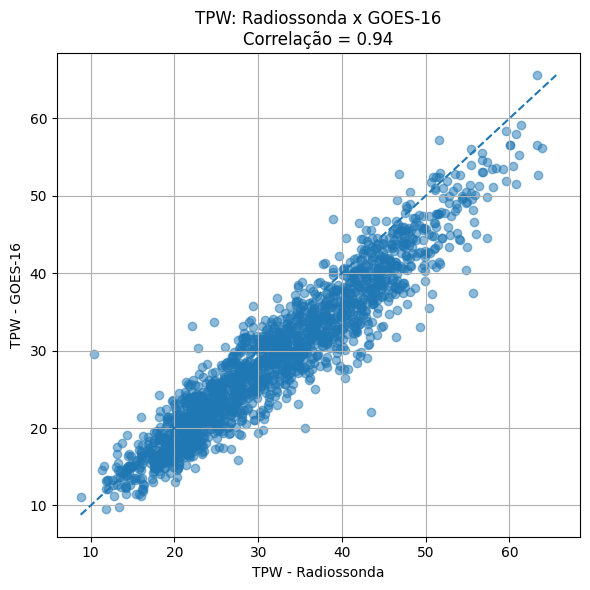

CAPE pares válidos: 1750


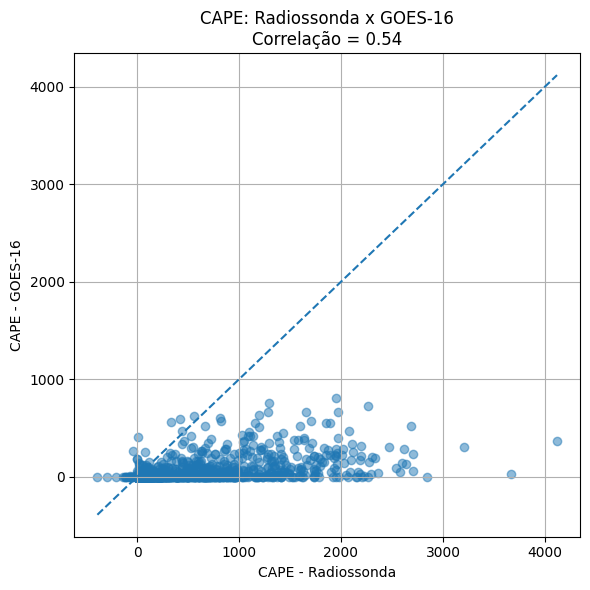

Lifted Index pares válidos: 1750


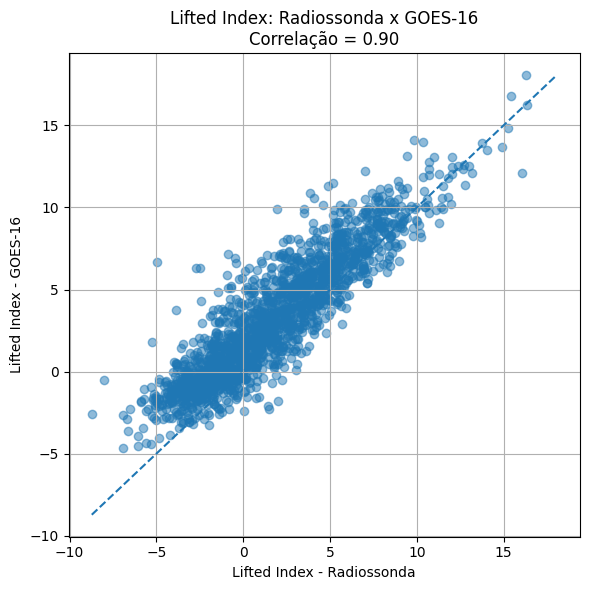

In [ ]:
import matplotlib.pyplot as plt

plot_pairs = [
    ("sat_TPWF_TPW", "tpw_radiosonde", "TPW"),
    ("sat_DSIF_CAPE", "cape_radiosonde", "CAPE"),
    ("sat_DSIF_LI", "li_radiosonde", "Lifted Index"),
]

for sat_col, radio_col, title in plot_pairs:
    valid = comparison_df[[sat_col, radio_col]].copy()

    valid[sat_col] = pd.to_numeric(valid[sat_col], errors="coerce")
    valid[radio_col] = pd.to_numeric(valid[radio_col], errors="coerce")

    valid = valid.dropna()

    print(title, "pares válidos:", len(valid))

    if len(valid) == 0:
        continue

    corr = valid[sat_col].corr(valid[radio_col])

    plt.figure(figsize=(6, 6))
    plt.scatter(valid[radio_col], valid[sat_col], alpha=0.5)

    min_val = min(valid[radio_col].min(), valid[sat_col].min())
    max_val = max(valid[radio_col].max(), valid[sat_col].max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel(f"{title} - Radiossonda")
    plt.ylabel(f"{title} - GOES-16")
    plt.title(f"{title}: Radiossonda x GOES-16\nCorrelação = {corr:.2f}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

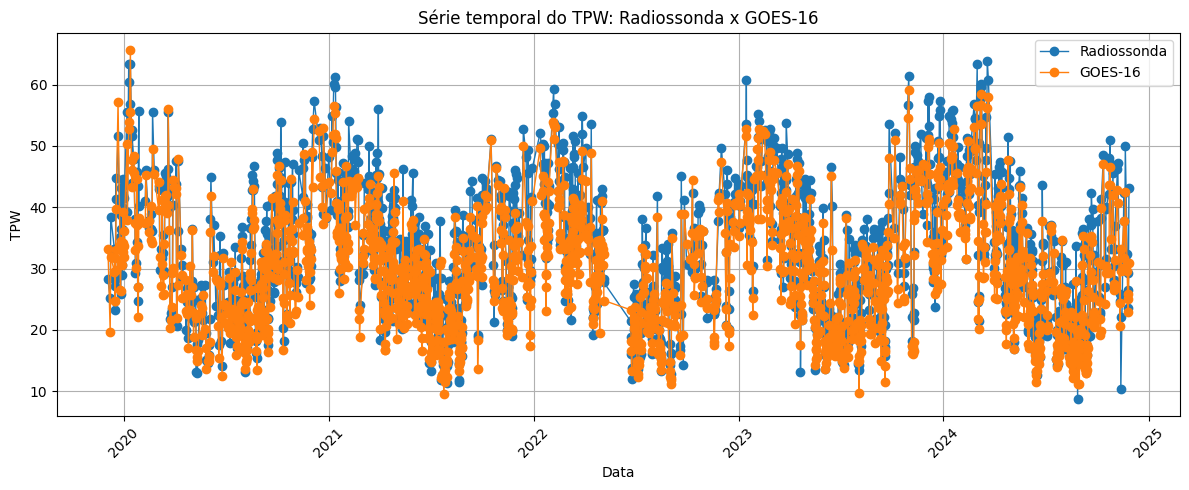

In [ ]:
def plot_monthly_series(df, sat_col, radio_col, title, ylabel):
    valid = df[["datetime", sat_col, radio_col]].copy()

    valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")
    valid[sat_col] = pd.to_numeric(valid[sat_col], errors="coerce")
    valid[radio_col] = pd.to_numeric(valid[radio_col], errors="coerce")

    valid = valid.dropna().sort_values("datetime")

    print(title, "pares válidos:", len(valid))

    if len(valid) == 0:
        return

    monthly = (
        valid
        .set_index("datetime")
        .resample("M")
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 5))

    plt.plot(
        monthly["datetime"],
        monthly[radio_col],
        label="Radiossonda",
        marker="o"
    )

    plt.plot(
        monthly["datetime"],
        monthly[sat_col],
        label="GOES-16",
        marker="o"
    )

    plt.xlabel("Data")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_monthly_series(
    comparison_df,
    "sat_TPWF_TPW",
    "tpw_radiosonde",
    "Evolução mensal do TPW: Radiossonda x GOES-16",
    "TPW médio mensal"
)

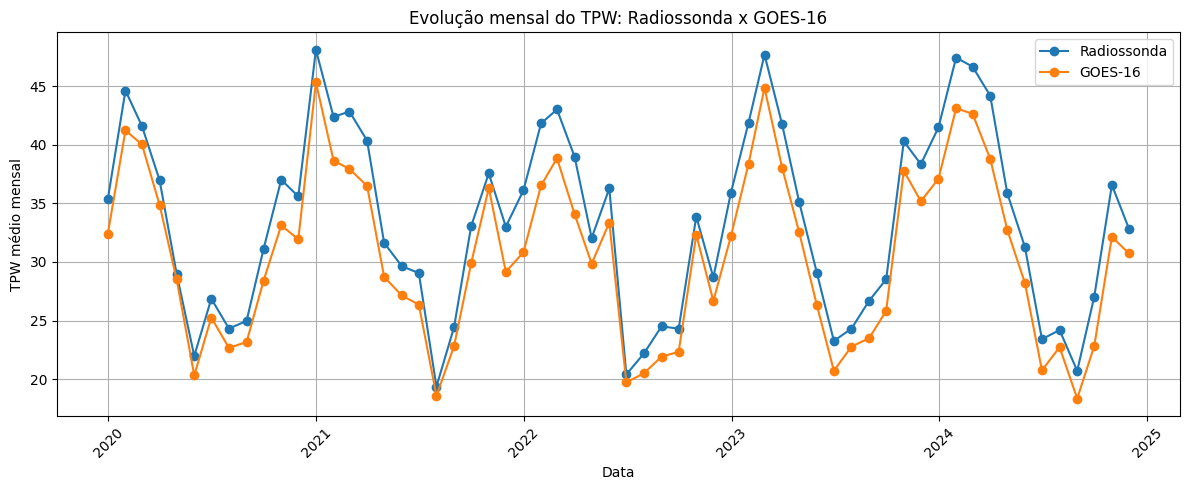

In [ ]:
#O GOES-16 acompanha a variação temporal da radiossonda?
valid = comparison_df[[
    "datetime",
    "tpw_radiosonde",
    "sat_TPWF_TPW"
]].copy()

valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")
valid["tpw_radiosonde"] = pd.to_numeric(valid["tpw_radiosonde"], errors="coerce")
valid["sat_TPWF_TPW"] = pd.to_numeric(valid["sat_TPWF_TPW"], errors="coerce")

valid = valid.dropna().sort_values("datetime")

monthly = (
    valid
    .set_index("datetime")
    .resample("M")
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly["datetime"],
    monthly["tpw_radiosonde"],
    label="Radiossonda",
    marker="o"
)

plt.plot(
    monthly["datetime"],
    monthly["sat_TPWF_TPW"],
    label="GOES-16",
    marker="o"
)

plt.xlabel("Data")
plt.ylabel("TPW médio mensal")
plt.title("Evolução mensal do TPW: Radiossonda x GOES-16")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

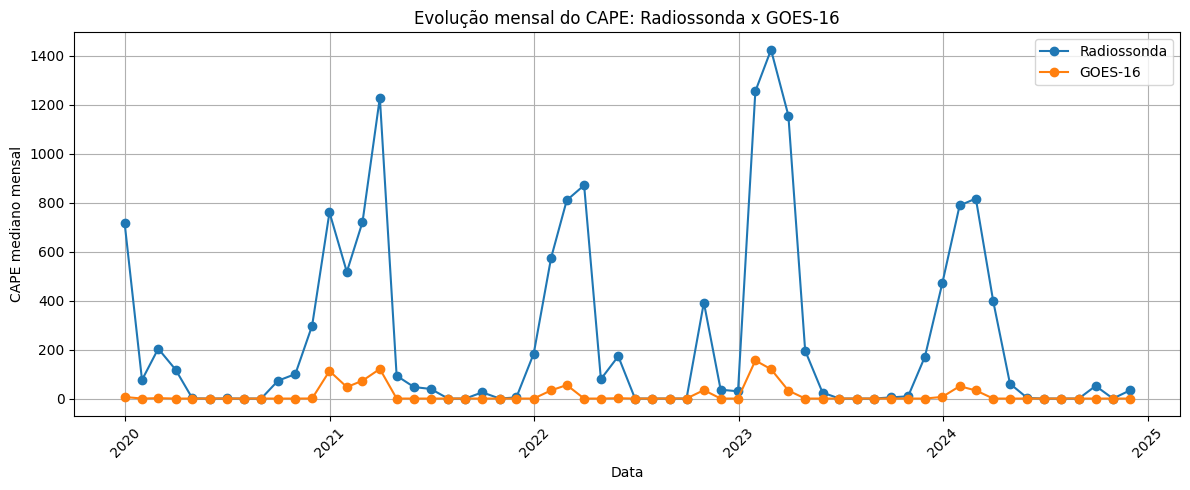

In [ ]:
valid = comparison_df[[
    "datetime",
    "cape_radiosonde",
    "sat_DSIF_CAPE"
]].copy()

valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")
valid["cape_radiosonde"] = pd.to_numeric(valid["cape_radiosonde"], errors="coerce")
valid["sat_DSIF_CAPE"] = pd.to_numeric(valid["sat_DSIF_CAPE"], errors="coerce")

valid = valid.dropna().sort_values("datetime")

monthly = (
    valid
    .set_index("datetime")
    .resample("M")
    .median()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly["datetime"],
    monthly["cape_radiosonde"],
    label="Radiossonda",
    marker="o"
)

plt.plot(
    monthly["datetime"],
    monthly["sat_DSIF_CAPE"],
    label="GOES-16",
    marker="o"
)

plt.xlabel("Data")
plt.ylabel("CAPE mediano mensal")
plt.title("Evolução mensal do CAPE: Radiossonda x GOES-16")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

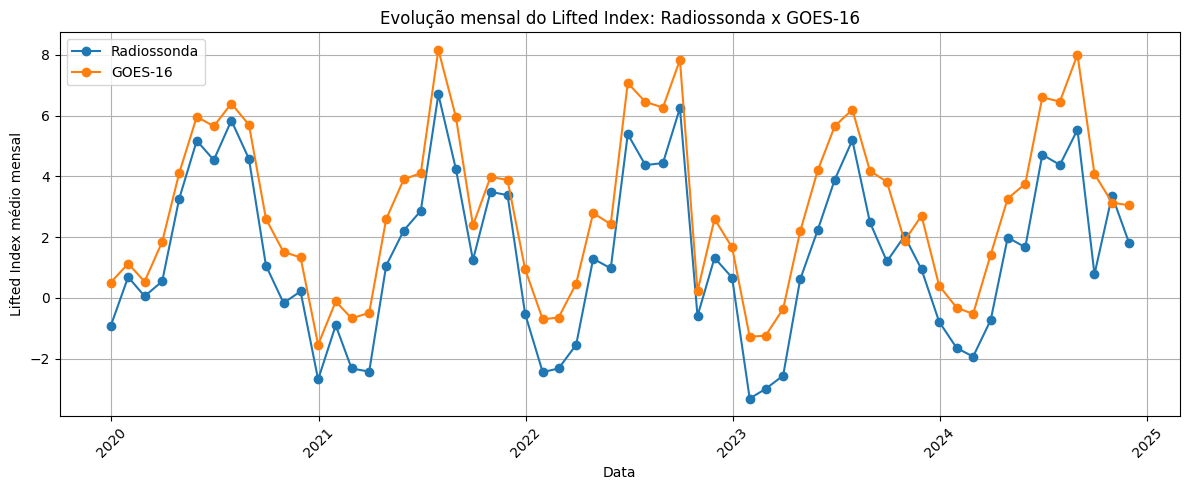

In [ ]:
valid = comparison_df[[
    "datetime",
    "li_radiosonde",
    "sat_DSIF_LI"
]].copy()

valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")
valid["li_radiosonde"] = pd.to_numeric(valid["li_radiosonde"], errors="coerce")
valid["sat_DSIF_LI"] = pd.to_numeric(valid["sat_DSIF_LI"], errors="coerce")

valid = valid.dropna().sort_values("datetime")

monthly = (
    valid
    .set_index("datetime")
    .resample("M")
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly["datetime"],
    monthly["li_radiosonde"],
    label="Radiossonda",
    marker="o"
)

plt.plot(
    monthly["datetime"],
    monthly["sat_DSIF_LI"],
    label="GOES-16",
    marker="o"
)

plt.xlabel("Data")
plt.ylabel("Lifted Index médio mensal")
plt.title("Evolução mensal do Lifted Index: Radiossonda x GOES-16")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#quando o satelite erra mais
import pandas as pd
import matplotlib.pyplot as plt

def plot_error_series(df, sat_col, radio_col, title, ylabel):
    valid = df[["datetime", sat_col, radio_col]].copy()

    valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")
    valid[sat_col] = pd.to_numeric(valid[sat_col], errors="coerce")
    valid[radio_col] = pd.to_numeric(valid[radio_col], errors="coerce")

    valid = valid.dropna().sort_values("datetime")

    print(title, "pares válidos:", len(valid))

    if len(valid) == 0:
        print("Sem dados válidos.")
        return

    valid["erro"] = valid[sat_col] - valid[radio_col]

    plt.figure(figsize=(12, 4))

    plt.plot(
        valid["datetime"],
        valid["erro"],
        linewidth=1
    )

    plt.axhline(0, linestyle="--")

    plt.xlabel("Data")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Erro do TPW ao longo do tempo pares válidos: 1752


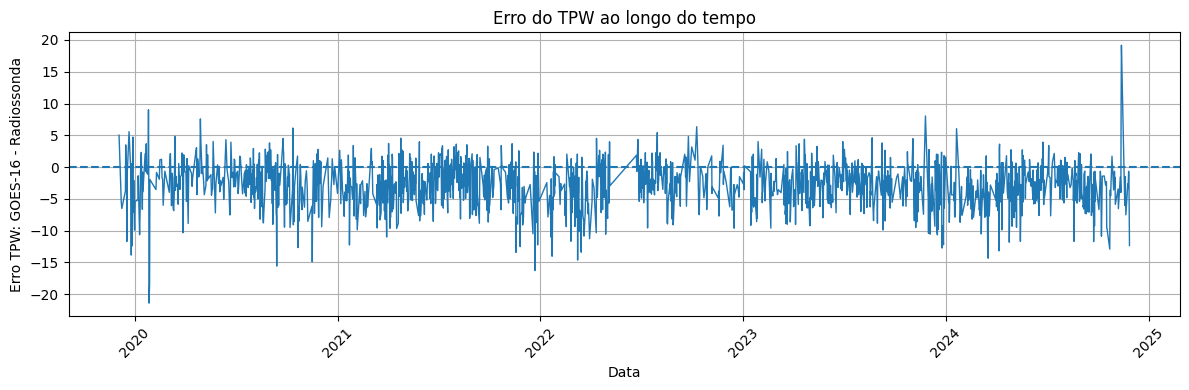

Erro do CAPE ao longo do tempo pares válidos: 1750


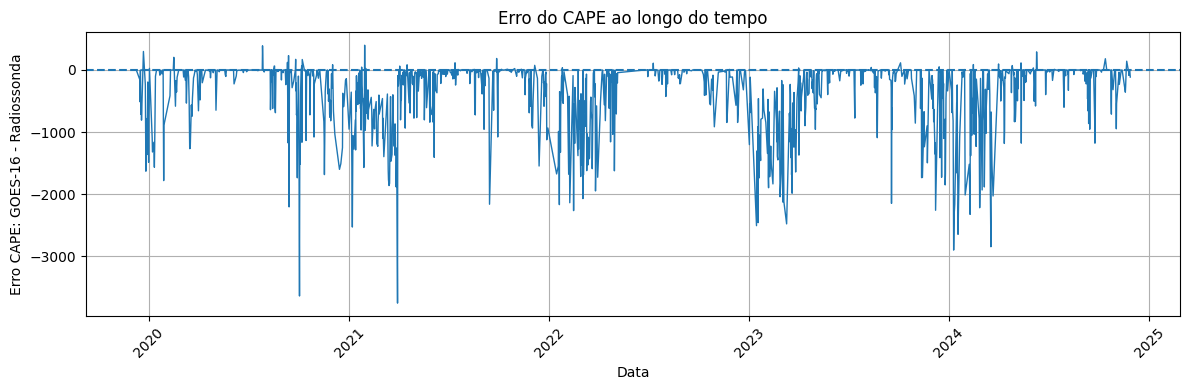

Erro do Lifted Index ao longo do tempo pares válidos: 1750


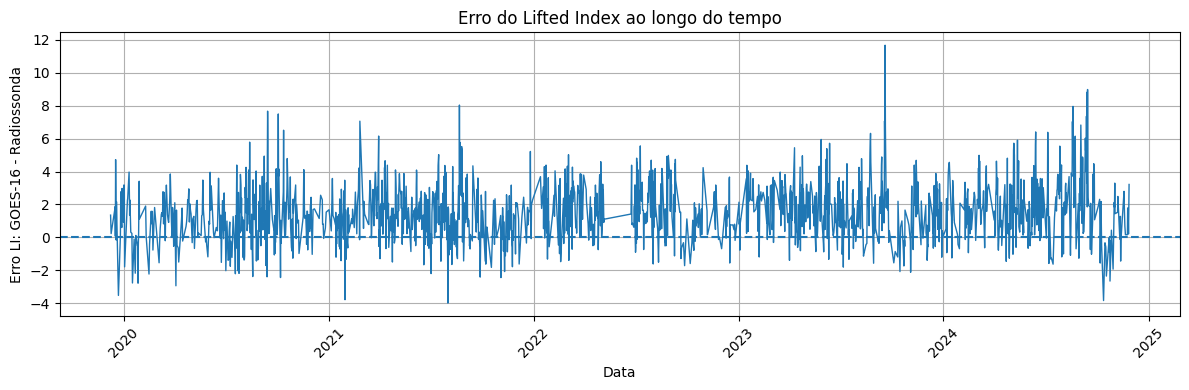

In [ ]:

plot_error_series(
    comparison_df,
    "sat_TPWF_TPW",
    "tpw_radiosonde",
    "Erro do TPW ao longo do tempo",
    "Erro TPW: GOES-16 - Radiossonda"
)

plot_error_series(
    comparison_df,
    "sat_DSIF_CAPE",
    "cape_radiosonde",
    "Erro do CAPE ao longo do tempo",
    "Erro CAPE: GOES-16 - Radiossonda"
)

plot_error_series(
    comparison_df,
    "sat_DSIF_LI",
    "li_radiosonde",
    "Erro do Lifted Index ao longo do tempo",
    "Erro LI: GOES-16 - Radiossonda"
)

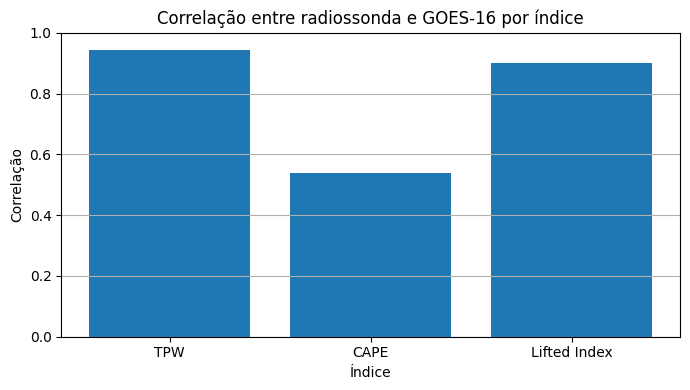

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    metrics_df["indice"],
    metrics_df["correlation"]
)

plt.ylim(0, 1)

plt.xlabel("Índice")
plt.ylabel("Correlação")
plt.title("Correlação entre radiossonda e GOES-16 por índice")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

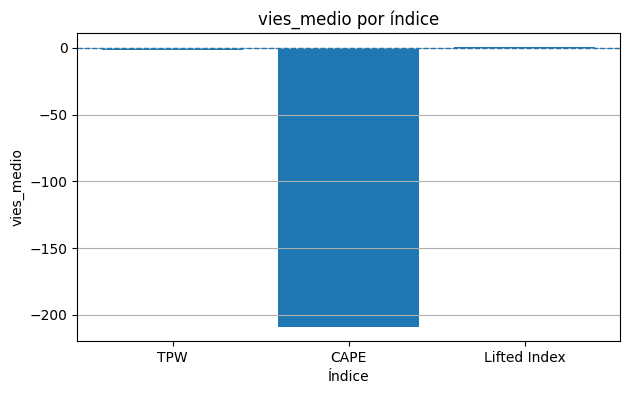

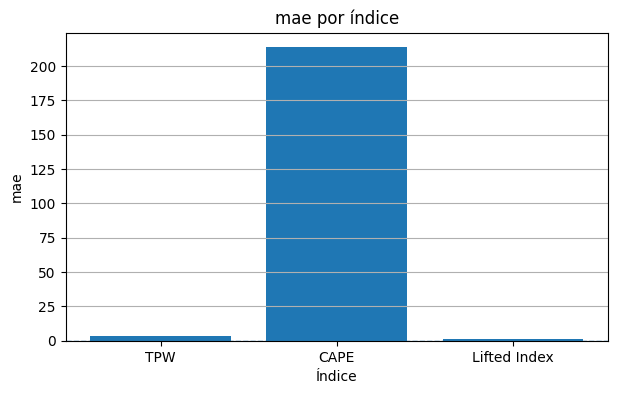

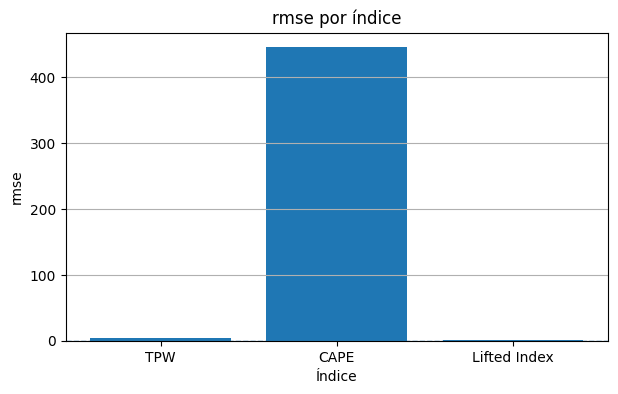

In [ ]:
metric_cols = ["vies_medio", "mae", "rmse"]

for metric in metric_cols:
    plt.figure(figsize=(7, 4))

    plt.bar(metrics_df["indice"], metrics_df[metric])

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel("Índice")
    plt.ylabel(metric)
    plt.title(f"{metric} por índice")
    plt.grid(axis="y")
    plt.show()